# Deep Learning Breast Cancer Detection from Mammograms

**Shivani Bava**  
**CM3070 Final Year Project**

This notebook implements a deep-learning pipeline for benign–malignant classification of full mammograms using the CBIS-DDSM dataset. The project investigates CNN network scaling, progressive regularisation, transfer learning with VGG16 and ResNet50, validation-based model and threshold selection, held-out test evaluation, patient-level bootstrap confidence intervals, Grad-CAM explainability, and an interactive Gradio research prototype.

The final system is intended for research purposes only and is not a clinically validated diagnostic tool.

# 1. Dataset Setup and Loading
Loads the CBIS-DDSM files from Google Drive and inspects the mass, calcification and DICOM metadata required for the experiments.


In [1]:
# Mount Google Drive and read the CBIS-DDSM dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Inspect the CBIS-DDSM directory structure
import os

BASE = '/content/drive/MyDrive/archive'

def show_tree(path, prefix='', max_depth=2, depth=0):
    if depth > max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except PermissionError:
        return
    dirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    files = [e for e in entries if os.path.isfile(os.path.join(path, e))]

    for d in dirs[:10]:
        print(f'{prefix}{d}/')
        show_tree(os.path.join(path, d), prefix + '  ', max_depth, depth + 1)
    if files:
        print(f'{prefix}[{len(files)} files] e.g. {files[:3]}')

show_tree(BASE)

import shutil

# Store model checkpoints in Google Drive
CHECKPOINT_DIR = f'{BASE}/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint_to_drive(filename):
    if os.path.exists(filename):
        dest = os.path.join(CHECKPOINT_DIR, filename)
        shutil.copy(filename, dest)
        print(f"Saved {filename} -> {dest}")
    else:
        print(f"WARNING: {filename} not found, nothing copied")

checkpoints/
  [1 files] e.g. ['best_model.keras']
csv/
  [6 files] e.g. ['calc_case_description_test_set.csv', 'calc_case_description_train_set.csv', 'dicom_info.csv']
jpeg/
  1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132/
    [2 files] e.g. ['1-263.jpg', '2-241.jpg']
  1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547/
    [1 files] e.g. ['1-126.jpg']
  1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869/
    [1 files] e.g. ['1-231.jpg']
  1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647/
    [1 files] e.g. ['1-111.jpg']
  1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962/
    [2 files] e.g. ['1-031.jpg', '2-011.jpg']
  1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884/
    [1 files] e.g. ['1-108.jpg']
  1.3.6.1.4.1.9590.100.1.2.100631678311747240317898717702514834166/
    [1 files] e.g. ['1-031.jpg']
  1.3.6.1.4.1.9590.100.1.2.100632214012866120117337678502539182046/
    [1 files] e.g. ['1-07

In [3]:
# List the CSV files available in the dataset
import os
BASE = '/content/drive/MyDrive/archive'
print(os.listdir(f'{BASE}/csv'))

['calc_case_description_train_set.csv', 'calc_case_description_test_set.csv', 'dicom_info.csv', 'mass_case_description_test_set.csv', 'mass_case_description_train_set.csv', 'meta.csv']


In [4]:
# Load mass case description CSV (benign/malignant)
import pandas as pd

BASE = '/content/drive/MyDrive/archive'

mass_train = pd.read_csv(f'{BASE}/csv/mass_case_description_train_set.csv')
print(mass_train.columns.tolist())
print(mass_train.shape)
mass_train.head(3)

# Load calcification cases and combine with mass cases
calc_train = pd.read_csv(f'{BASE}/csv/calc_case_description_train_set.csv')
print("Calc train columns:", calc_train.columns.tolist())
print("Calc train shape:", calc_train.shape)

mass_train = pd.concat([mass_train, calc_train], ignore_index=True)
print("Combined train (mass + calc):", mass_train.shape)

['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
(1318, 14)
Calc train columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
Calc train shape: (1546, 14)
Combined train (mass + calc): (2864, 17)


## 1.1 Identify and Link Full Mammogram Images
Filters the DICOM metadata to identify full mammogram images and investigates how the case-description records can be linked to their corresponding image files.

In [5]:
# Load DICOM metadata CSV
dicom_info = pd.read_csv(f'{BASE}/csv/dicom_info.csv')
print(dicom_info.columns.tolist())
print(dicom_info.shape)
dicom_info.head(5)

['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']
(10237, 38)


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [6]:
# Identify full mammogram files and resolve their paths
full_mammo = dicom_info[dicom_info['SeriesDescription'] == 'full mammogram images'].copy()
print(f"Full mammogram entries: {len(full_mammo)}")

full_mammo['real_path'] = full_mammo['image_path'].str.replace('CBIS-DDSM/', '', regex=False)
full_mammo['real_path'] = BASE + '/' + full_mammo['real_path']

print(full_mammo[['image_path', 'real_path']].head(3))

# Sanity check
import os
test_path = full_mammo['real_path'].iloc[0]
print("Exists:", os.path.exists(test_path))

Full mammogram entries: 2857
                                           image_path  \
1   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...   
2   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...   
11  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...   

                                            real_path  
1   /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
2   /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
11  /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
Exists: True


In [7]:
# Match the two CSVs on the DICOM UID
import re

def extract_uid(path):
    """Pull the long DICOM UID out of a path string."""
    match = re.search(r'1\.3\.6\.1\.4\.1\.9590\.100\.1\.2\.\d+', str(path))
    return match.group(0) if match else None

# Extract UID from dicom_info's full mammogram rows
full_mammo['uid'] = full_mammo['image_path'].apply(extract_uid)

# Extract UID from the mass CSV's image file path column
mass_train['uid'] = mass_train['image file path'].apply(extract_uid)

print(full_mammo[['uid', 'real_path']].head(3))
print(mass_train[['uid', 'pathology']].head(3))

# Check overlap
print("UIDs in full_mammo:", full_mammo['uid'].notna().sum())
print("UIDs in mass_train:", mass_train['uid'].notna().sum())
print("Matching UIDs:", len(set(full_mammo['uid']) & set(mass_train['uid'])))

                                                  uid  \
1   1.3.6.1.4.1.9590.100.1.2.248386742010678582309...   
2   1.3.6.1.4.1.9590.100.1.2.267213171011171858918...   
11  1.3.6.1.4.1.9590.100.1.2.210396893911234385024...   

                                            real_path  
1   /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
2   /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
11  /content/drive/MyDrive/archive/jpeg/1.3.6.1.4....  
                                                 uid  pathology
0  1.3.6.1.4.1.9590.100.1.2.422112722213189649807...  MALIGNANT
1  1.3.6.1.4.1.9590.100.1.2.319478999311971442426...  MALIGNANT
2  1.3.6.1.4.1.9590.100.1.2.347107867812656628709...     BENIGN
UIDs in full_mammo: 2857
UIDs in mass_train: 2864
Matching UIDs: 0


In [8]:
# Compare extracted DICOM UIDs between mammogram metadata and case records
pd.set_option('display.max_colwidth', None)

print("From full_mammo:")
print(full_mammo['uid'].iloc[0])
print()
print("From mass_train:")
print(mass_train['uid'].iloc[0])

From full_mammo:
1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849

From mass_train:
1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994


In [9]:
# Inspect case-description fields and matched mammogram metadata
print(mass_train[['patient_id', 'left or right breast', 'image view', 'image file path']].head(5))
print()
print(full_mammo['real_path'].iloc[0])
print()
print(dicom_info[['PatientID', 'SeriesDescription']].head(10))

  patient_id left or right breast image view  \
0    P_00001                 LEFT         CC   
1    P_00001                 LEFT        MLO   
2    P_00004                 LEFT         CC   
3    P_00004                 LEFT        MLO   
4    P_00004                RIGHT        MLO   

                                                                                                                                                                image file path  
0    Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm  
1   Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm  
2     Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/000000.dcm  

## 1.2 Construct the Image-Level Mass + Calcification Dataset
Combines mass and calcification records into one labelled record per full mammogram.

In [10]:
# Load and combine mass and calcification test-set records
mass_test = pd.read_csv(f'{BASE}/csv/mass_case_description_test_set.csv')
calc_test = pd.read_csv(f'{BASE}/csv/calc_case_description_test_set.csv')
mass_test = pd.concat([mass_test, calc_test], ignore_index=True)
print("Combined test (mass + calc):", mass_test.shape)

mass_test['case_id'] = mass_test['image file path'].str.split('/').str[0]

Combined test (mass + calc): (704, 17)


In [11]:
# Construct image-level records and recover missing full mammograms
import re
import numpy as np
import pandas as pd

_nan = dicom_info[dicom_info['SeriesDescription'].isna()].copy()
_nan['img_key'] = (_nan['PatientID'].astype(str).str.strip()
                   .str.extract(r'^(P_\d+_(?:LEFT|RIGHT)_(?:CC|MLO))\.dcm$')[0])
_nan = _nan.dropna(subset=['img_key'])
_nan['real_path'] = BASE + '/' + _nan['image_path'].str.replace('CBIS-DDSM/', '', regex=False)
fallback_paths = dict(zip(_nan['img_key'], _nan['real_path']))
print("Fallback full-image lookup entries:", len(fallback_paths))


def build_labelled_df(case_df, full_mammo_df, name=''):
    """One row per IMAGE FILE, with a real patient_id.

    - label = 1 if ANY lesion on that image is MALIGNANT (worst finding wins)
    - images missing from full_mammo are looked up via the NaN-description fallback
    """
    c = case_df.copy()
    c['case_id'] = c['image file path'].str.split('/').str[0]
    c['is_malignant'] = (c['pathology'] == 'MALIGNANT').astype(int)

    per_image = (c.groupby('case_id', as_index=False)
                   .agg(label=('is_malignant', 'max'),
                        n_label_values=('is_malignant', 'nunique')))
    print(f"[{name}] lesion rows: {len(c)} -> unique images: {len(per_image)}")
    print(f"[{name}] images with mixed benign+malignant lesions "
          f"(labelled malignant): {(per_image['n_label_values'] > 1).sum()}")

    lookup = (full_mammo_df.drop_duplicates('PatientID')[['PatientID', 'real_path']]
              .rename(columns={'PatientID': 'case_id'}))
    out = per_image.merge(lookup, on='case_id', how='left')

    # Fallback for images not found via the normal route
    missing = out['real_path'].isna()
    key = out.loc[missing, 'case_id'].str.replace(
        r'^(?:Mass|Calc)-(?:Test|Training)_', '', regex=True)
    out.loc[missing, 'real_path'] = key.map(fallback_paths)
    print(f"[{name}] not found normally: {missing.sum()} | "
          f"recovered via fallback: {missing.sum() - out['real_path'].isna().sum()} | "
          f"still missing: {out['real_path'].isna().sum()}")
    out = out.dropna(subset=['real_path'])

    n_before = len(out)
    out = (out.groupby('real_path', as_index=False)
              .agg(PatientID=('case_id', 'first'), label=('label', 'max')))
    print(f"[{name}] merged {n_before - len(out)} duplicate image files")

    out['patient_id'] = out['PatientID'].str.extract(r'(P_\d+)')[0]
    print(f"[{name}] final images: {len(out)} | real patients: {out['patient_id'].nunique()} "
          f"| malignant ratio: {out['label'].mean():.3f}")
    return out[['PatientID', 'patient_id', 'real_path', 'label']].reset_index(drop=True)


merged      = build_labelled_df(mass_train, full_mammo, 'train')
merged_test = build_labelled_df(mass_test,  full_mammo, 'test')

shared = set(merged['patient_id']) & set(merged_test['patient_id'])
print(f"\nPatients in BOTH official train and test: {len(shared)} (want 0)")
print("Test label counts:\n", merged_test['label'].value_counts())

Fallback full-image lookup entries: 246
[train] lesion rows: 2864 -> unique images: 2458
[train] images with mixed benign+malignant lesions (labelled malignant): 13
[train] not found normally: 0 | recovered via fallback: 0 | still missing: 0
[train] merged 0 duplicate image files
[train] final images: 2458 | real patients: 1248 | malignant ratio: 0.452
[test] lesion rows: 704 -> unique images: 645
[test] images with mixed benign+malignant lesions (labelled malignant): 4
[test] not found normally: 246 | recovered via fallback: 246 | still missing: 0
[test] merged 0 duplicate image files
[test] final images: 645 | real patients: 349 | malignant ratio: 0.409

Patients in BOTH official train and test: 31 (want 0)
Test label counts:
 label
0    381
1    264
Name: count, dtype: int64


## 1.3 Remove Patient-Level Train–Test Leakage
Identifies patients appearing in both the combined training and test partitions and removes those patients from the training pool while retaining them in the held-out test set. This ensures that no patient contributes images to both development and final testing.

In [12]:
# Remove patient overlap between development and test sets
shared_patients = (
    set(merged['patient_id'])
    & set(merged_test['patient_id'])
)

print("Shared patients BEFORE fix:", len(shared_patients))

# Remove overlapping patients from training data
merged = merged[
    ~merged['patient_id'].isin(shared_patients)
].reset_index(drop=True)

# Double check
shared_after = (
    set(merged['patient_id'])
    & set(merged_test['patient_id'])
)

print("Training images after removing overlap:", len(merged))
print("Training patients after removing overlap:", merged['patient_id'].nunique())
print("Test images:", len(merged_test))
print("Test patients:", merged_test['patient_id'].nunique())
print("Shared patients AFTER fix:", len(shared_after))

# Safety check
assert len(shared_after) == 0, \
    "ERROR: Some patients still appear in both train and test!"

print("\nTrain/test patient leakage removed successfully.")

Shared patients BEFORE fix: 31
Training images after removing overlap: 2394
Training patients after removing overlap: 1217
Test images: 645
Test patients: 349
Shared patients AFTER fix: 0

Train/test patient leakage removed successfully.


## 1.4 Data Integrity Check — Recovering Missing Full Mammograms
Investigates full mammograms whose SeriesDescription metadata is missing and verifies that the fallback matching procedure recovers genuine full mammogram images rather than cropped images or ROI masks.

SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
NaN                       566
Name: count, dtype: int64

P_00038 -> 16 rows
                          PatientID SeriesDescription                                                                                 image_path
697   Calc-Test_P_00038_RIGHT_MLO_2    cropped images  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.326152312412979080929913875463824504551/1-250.jpg
698         P_00038_RIGHT_MLO_2.dcm               NaN  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.326152312412979080929913875463824504551/2-102.jpg
1604  Calc-Test_P_00038_RIGHT_MLO_1    cropped images  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.126295284812046209819441424913058621714/1-249.jpg
1605        P_00038_RIGHT_MLO_1.dcm               NaN  CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.126295284812046209819441424913058621714/2-101.jpg
1885          P_00038_RIGHT_MLO.dcm               NaN   CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100

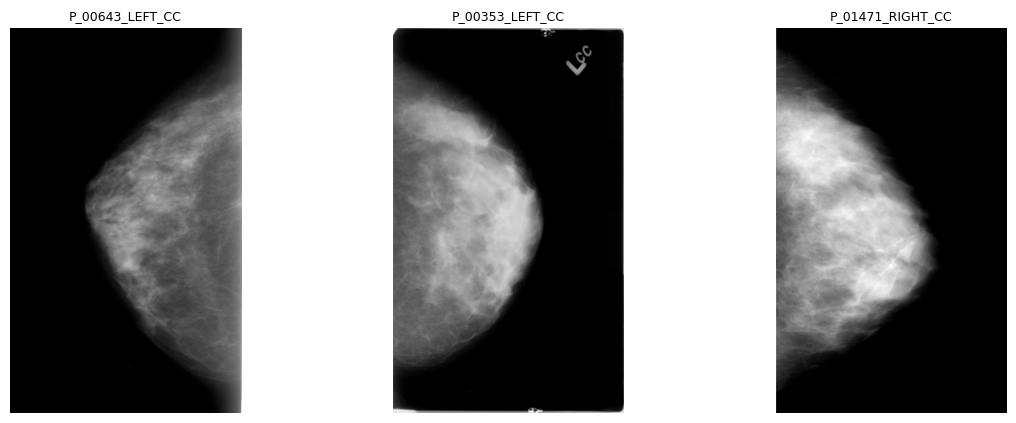

In [13]:
# Validate recovered full mammogram mappings
print(dicom_info['SeriesDescription'].value_counts(dropna=False))
print()

for pid in ['P_00038', 'P_00041']:
    hits = dicom_info[
        dicom_info['PatientID'].astype(str).str.contains(pid, na=False)
    ]

    print(pid, '->', len(hits), 'rows')

    print(
        hits[
            ['PatientID', 'SeriesDescription', 'image_path']
        ].head(6).to_string()
    )

    print()

print(
    "Folders in jpeg/:",
    len(os.listdir(f'{BASE}/jpeg'))
)

# Check NaN-Description rows
import re
import matplotlib.pyplot as plt
from PIL import Image

nan_rows = dicom_info[
    dicom_info['SeriesDescription'].isna()
].copy()

pat = r'^(P_\d+_(?:LEFT|RIGHT)_(?:CC|MLO))\.dcm$'

nan_rows['img_key'] = (
    nan_rows['PatientID']
    .astype(str)
    .str.strip()
    .str.extract(pat)[0]
)

cand = nan_rows.dropna(
    subset=['img_key']
).copy()

cand['real_path'] = (
    BASE
    + '/'
    + cand['image_path'].str.replace(
        'CBIS-DDSM/',
        '',
        regex=False
    )
)


print(
    "NaN-description rows:",
    len(nan_rows)
)

print(
    "...of which look like full-image IDs:",
    len(cand)
)

print(
    "Unique image keys:",
    cand['img_key'].nunique(),
    "| duplicate keys:",
    cand['img_key'].duplicated().sum()
)

# Check if unmatched test images can be recovered
test_ids = (
    mass_test['image file path']
    .str.split('/')
    .str[0]
    .drop_duplicates()
)

unmatched = sorted(
    set(test_ids)
    - set(full_mammo['PatientID'])
)

unmatched_key = (
    pd.Series(unmatched)
    .str.replace(
        r'^(Mass|Calc)-(Test|Training)_',
        '',
        regex=True
    )
)

recovered = unmatched_key.isin(
    set(cand['img_key'])
)

print(
    f"\nUnmatched test images: {len(unmatched)} "
    f"| recoverable via NaN rows: {recovered.sum()}"
)

# Visual sanity check
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5)
)

for ax, (_, r) in zip(
    axes,
    cand.sample(
        3,
        random_state=0
    ).iterrows()
):

    im = Image.open(
        r['real_path']
    )

    a = np.array(im)

    print(
        f"{r['img_key']}: "
        f"size={im.size}, "
        f"unique gray values={len(np.unique(a))}, "
        f"mean={a.mean():.1f}"
    )

    ax.imshow(
        im.resize((300, 500)),
        cmap='gray'
    )

    ax.set_title(
        r['img_key'],
        fontsize=9
    )

    ax.axis('off')

plt.show()

# 2. Patient-Level Data Split and Input Pipeline
Creates patient-disjoint train, validation and test partitions and the TensorFlow input pipeline.

In [14]:
# Create patient-disjoint train, validation and test partitions
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

IMG_SIZE = 256
BATCH_SIZE = 16

RUN_TAG = "final_clean_v2"

# Patient-level train/validation split
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score

N_SPLITS = 7

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf.split(
        merged,
        y=merged['label'],
        groups=merged['patient_id']   # REAL patient ID
    )
)

train_df = merged.iloc[train_idx].reset_index(drop=True)
val_df   = merged.iloc[val_idx].reset_index(drop=True)

# Separate official test set
test_df = merged_test.copy().reset_index(drop=True)

# Split information
print("TRAIN")
print("Images:", len(train_df))
print("Patients:", train_df['patient_id'].nunique())
print("Malignant ratio:", round(train_df['label'].mean(), 3))

print("\nVALIDATION")
print("Images:", len(val_df))
print("Patients:", val_df['patient_id'].nunique())
print("Malignant ratio:", round(val_df['label'].mean(), 3))

print("\nTEST")
print("Images:", len(test_df))
print("Patients:", test_df['patient_id'].nunique())
print("Malignant ratio:", round(test_df['label'].mean(), 3))

# Leakage checks
train_patients = set(train_df['patient_id'])
val_patients   = set(val_df['patient_id'])
test_patients  = set(test_df['patient_id'])

train_val_overlap  = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap   = val_patients & test_patients

print("\nPATIENT OVERLAP CHECKS")
print("Train / validation overlap:", len(train_val_overlap))
print("Train / test overlap:", len(train_test_overlap))
print("Validation / test overlap:", len(val_test_overlap))

assert len(train_val_overlap) == 0, "ERROR: train/validation leakage!"
assert len(train_test_overlap) == 0, "ERROR: train/test leakage!"
assert len(val_test_overlap) == 0, "ERROR: validation/test leakage!"

print("\nAll patient-level leakage checks passed.")

# Naive baseline - Validation set
majority_class = int(train_df['label'].value_counts().idxmax())

naive_val_predictions = np.full(len(val_df), majority_class)
naive_val_scores = np.full(len(val_df), float(majority_class))

naive_val_accuracy = accuracy_score(val_df['label'], naive_val_predictions)
naive_val_auc = roc_auc_score(val_df['label'], naive_val_scores)

print("\nNAIVE VALIDATION BASELINE")
print("Majority class:", "Malignant" if majority_class == 1 else "Benign")
print("Validation Accuracy:", round(naive_val_accuracy, 3))
print("Validation AUC:", round(naive_val_auc, 3))

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

# Cached datasets
import os

CACHE_DIR = os.path.join(BASE, "tf_cache", "final_clean_v1")
os.makedirs(CACHE_DIR, exist_ok=True)

print("Cache folder:", CACHE_DIR)


def make_dataset(df, cache_name, shuffle=False, augment=False):
    paths = df['real_path'].values
    labels = df['label'].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Read + resize + normalise original mammogram
    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Save processed 256x256 images
    cache_path = os.path.join(CACHE_DIR, cache_name)
    ds = ds.cache(cache_path)

    # Augmentation after caching
    if augment:
        def aug(img, label):
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.clip_by_value(img, 0.0, 1.0)
            return img, label

        ds = ds.map(
            aug,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(
    train_df,
    cache_name="train_cache",
    shuffle=True,
    augment=True
)

val_ds = make_dataset(
    val_df,
    cache_name="val_cache"
)

test_ds = make_dataset(
    test_df,
    cache_name="test_cache"
)

print("Cached datasets created.")


TRAIN
Images: 2060
Patients: 1042
Malignant ratio: 0.447

VALIDATION
Images: 334
Patients: 175
Malignant ratio: 0.473

TEST
Images: 645
Patients: 349
Malignant ratio: 0.409

PATIENT OVERLAP CHECKS
Train / validation overlap: 0
Train / test overlap: 0
Validation / test overlap: 0

All patient-level leakage checks passed.

NAIVE VALIDATION BASELINE
Majority class: Benign
Validation Accuracy: 0.527
Validation AUC: 0.5
Cache folder: /content/drive/MyDrive/archive/tf_cache/final_clean_v1
Cached datasets created.


## 2.1 Model Checkpointing, Early Stopping and Recovery
Defines the shared training function used by all models. The best model is selected using validation AUC, completed models and histories are saved to Google Drive, early stopping limits unnecessary training, and interrupted runs can be restored.

In [15]:
# Configure shared checkpointing, early stopping and recovery
import os, json
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, BackupAndRestore

MODEL_DIR = os.path.join(BASE, "saved_models", RUN_TAG)
os.makedirs(MODEL_DIR, exist_ok=True)

def train_or_load(build_fn, name, train_ds, val_ds, epochs=20, patience=5):
    """build_fn: zero-arg function returning a compiled, ready-to-fit model.
    name: unique string id for this model (used in all its filenames).
    Returns (model, history_dict_or_None). history is None if loaded, not trained.
    """
    model_path   = os.path.join(MODEL_DIR, f"{name}_best.keras")
    history_path = os.path.join(MODEL_DIR, f"{name}_history.json")
    done_path    = os.path.join(MODEL_DIR, f"{name}_complete.txt")
    backup_dir   = os.path.join(MODEL_DIR, f"{name}_backup")

    if os.path.exists(model_path) and os.path.exists(done_path):
        print(f"[{name}] already trained -> loading from Drive, no retraining")
        model = tf.keras.models.load_model(model_path)
        history = None
        if os.path.exists(history_path):
            with open(history_path) as f:
                history = json.load(f)
        return model, history

    print(f"[{name}] not yet complete -> training now")
    model = build_fn()
    checkpoint = ModelCheckpoint(model_path, monitor="val_auc", mode="max",
                                  save_best_only=True, verbose=1)
    early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=patience,
                                restore_best_weights=True, verbose=1)
    backup = BackupAndRestore(backup_dir=backup_dir)

    h = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                  callbacks=[checkpoint, early_stop, backup])

    model = tf.keras.models.load_model(model_path)
    history_dict = {k: [float(x) for x in v] for k, v in h.history.items()}
    with open(history_path, "w") as f:
        json.dump(history_dict, f, indent=2)
    with open(done_path, "w") as f:
        f.write(f"{name} training completed.")

    print(f"[{name}] done -> model, history, and completion marker saved to Drive")
    return model, history_dict

# 3. Experiment 1 — Plain CNN Network Scale-Up
Compares four unregularised CNN architectures of increasing depth to investigate the effect of network capacity before regularisation is introduced.

In [16]:
# Train plain CNN scale-up models without augmentation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_ds_noaug = make_dataset(
    train_df, cache_name="train_cache", shuffle=True, augment=False
)

def build_plain_cnn(filters_list):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = inputs
    for f in filters_list:
        x = layers.Conv2D(f, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    m = models.Model(inputs, outputs)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

scaleup_configs = [
    ("scaleup_tiny",   [16, 32]),
    ("scaleup_small",  [16, 32, 64]),
    ("scaleup_medium", [16, 32, 64, 128]),
    ("scaleup_large",  [16, 32, 64, 128, 256]),
]

scaleup_results = []
SCALEUP_RESULTS_PATH = os.path.join(MODEL_DIR, "scaleup_results.csv")

for name, filters_list in scaleup_configs:
    print(f"\n=== {name} ===")
    m, hist = train_or_load(
        lambda filters_list=filters_list: build_plain_cnn(filters_list),
        name, train_ds_noaug, val_ds, epochs=30, patience=5
    )

    # Evaluate the saved best-validation model on training set
    train_auc = m.evaluate(train_ds_noaug, verbose=0)[2]

    val_probs = m.predict(val_ds, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)
    val_labels = val_df['label'].values

    val_auc = roc_auc_score(val_labels, val_probs)
    val_accuracy = accuracy_score(val_labels, val_preds)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)
    val_sensitivity = recall_score(val_labels, val_preds, zero_division=0)
    val_specificity = recall_score(val_labels, val_preds, pos_label=0, zero_division=0)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)

    scaleup_results.append({
        'Architecture': name,
        'Params': m.count_params(),
        'Train AUC': round(train_auc, 3),
        'Val AUC': round(val_auc, 3),
        'Val Accuracy': round(val_accuracy, 3),
        'Val Precision': round(val_precision, 3),
        'Val Sensitivity': round(val_sensitivity, 3),
        'Val Specificity': round(val_specificity, 3),
        'Val F1': round(val_f1, 3),
        'Gap (overfitting)': round(train_auc - val_auc, 3)
    })

    scaleup_df = pd.DataFrame(scaleup_results)
    scaleup_df.to_csv(SCALEUP_RESULTS_PATH, index=False)
    print(f"Results saved after {name}")

print("\n=== Network Scale-Up Summary ===")
scaleup_df = pd.DataFrame(scaleup_results)
print(scaleup_df)
print("\nSaved to:", SCALEUP_RESULTS_PATH)


=== scaleup_tiny ===
[scaleup_tiny] already trained -> loading from Drive, no retraining
Results saved after scaleup_tiny

=== scaleup_small ===
[scaleup_small] already trained -> loading from Drive, no retraining
Results saved after scaleup_small

=== scaleup_medium ===
[scaleup_medium] already trained -> loading from Drive, no retraining
Results saved after scaleup_medium

=== scaleup_large ===
[scaleup_large] already trained -> loading from Drive, no retraining
Results saved after scaleup_large

=== Network Scale-Up Summary ===
     Architecture  Params  Train AUC  Val AUC  Val Accuracy  Val Precision  \
0    scaleup_tiny    6977      0.585    0.640         0.533          0.667   
1   scaleup_small   27521      0.621    0.658         0.575          0.660   
2  scaleup_medium  105473      0.647    0.650         0.563          0.562   
3   scaleup_large  408833      0.649    0.672         0.563          0.573   

   Val Sensitivity  Val Specificity  Val F1  Gap (overfitting)  
0     

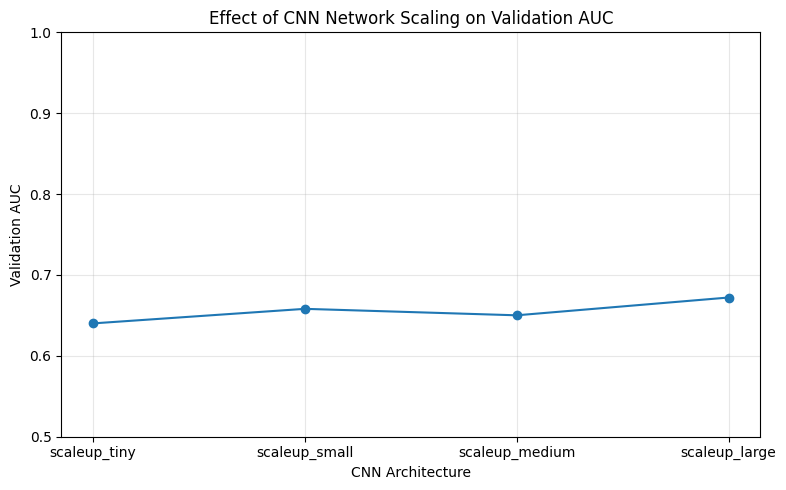

In [17]:
# Plot validation AUC across CNN scale-up architectures
plt.figure(figsize=(8, 5))
plt.plot(scaleup_df['Architecture'], scaleup_df['Val AUC'], marker='o')
plt.xlabel('CNN Architecture')
plt.ylabel('Validation AUC')
plt.title('Effect of CNN Network Scaling on Validation AUC')
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Scale-Up Interpretation

Increasing CNN capacity did not produce a consistent improvement in validation performance. The largest model achieved the highest validation AUC of 0.672, but this gain was modest relative to the increase in parameters, while the medium model achieved better sensitivity and F1-score at the default threshold. This suggests that increasing network size alone was not sufficient to substantially improve generalisation.

# 4. Experiment 2 — CNN Regularisation Ablation
Evaluates progressive addition of augmentation, dropout, batch normalisation and L2 regularisation.

In [18]:
# Run the progressive regularisation ablation
from tensorflow.keras import regularizers

def build_stage_cnn(use_bn=False, use_l2=False, use_dropout=False):
    reg = regularizers.l2(1e-4) if use_l2 else None

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, activation='relu', padding='same',
                           kernel_regularizer=reg)(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        return x

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = conv_block(inputs, 16)
    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    if use_dropout:
        x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    m = models.Model(inputs, outputs)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m


def full_val_metrics(m, ds_for_train_auc=None, train_auc_override=None):

    # Evaluate saved best-validation model
    train_auc = m.evaluate(train_ds_noaug, verbose=0)[2]

    val_probs = m.predict(val_ds, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)
    val_labels = val_df['label'].values

    return {
        'Train AUC': round(train_auc, 3),
        'Val AUC': round(roc_auc_score(val_labels, val_probs), 3),
        'Val Accuracy': round(accuracy_score(val_labels, val_preds), 3),
        'Val Precision': round(precision_score(val_labels, val_preds, zero_division=0), 3),
        'Val Sensitivity': round(recall_score(val_labels, val_preds, zero_division=0), 3),
        'Val Specificity': round(recall_score(val_labels, val_preds, pos_label=0, zero_division=0), 3),
        'Val F1': round(f1_score(val_labels, val_preds, zero_division=0), 3),
        'Gap (overfitting)': round(train_auc - roc_auc_score(val_labels, val_probs), 3)
    }

succession_results = []
stage_models = {}
stage_histories = {}
SUCCESSION_RESULTS_PATH = os.path.join(MODEL_DIR, "regularisation_results.csv")

print("\n=== cnn_plain (reusing scaleup_medium) ===")
plain_model, plain_hist = train_or_load(
    lambda: build_stage_cnn(use_bn=False, use_l2=False, use_dropout=False),
    "scaleup_medium", train_ds_noaug, val_ds, epochs=30, patience=5
)
stage_models["cnn_plain"] = plain_model
stage_histories["cnn_plain"] = plain_hist

train_auc_override = max(plain_hist['auc']) if plain_hist is not None else None
row = full_val_metrics(plain_model, train_ds_noaug, train_auc_override)
row['Stage'] = 'cnn_plain'
succession_results.append(row)
pd.DataFrame(succession_results).to_csv(SUCCESSION_RESULTS_PATH, index=False)
print("Plain CNN result reused from scaleup_medium.")

stages = [
    ("cnn_aug",                train_ds, False, False, False),
    ("cnn_aug_dropout",        train_ds, False, False, True),
    ("cnn_aug_dropout_bn",     train_ds, True,  False, True),
    ("cnn_final_regularised",  train_ds, True,  True,  True),
]

for name, ds, use_bn, use_l2, use_dropout in stages:
    print(f"\n=== {name} ===")
    m, hist = train_or_load(
        lambda use_bn=use_bn, use_l2=use_l2, use_dropout=use_dropout:
            build_stage_cnn(use_bn=use_bn, use_l2=use_l2, use_dropout=use_dropout),
        name, ds, val_ds, epochs=30, patience=5
    )
    stage_models[name] = m
    stage_histories[name] = hist

    train_auc_override = max(hist['auc']) if hist is not None else None
    row = full_val_metrics(m, ds, train_auc_override)
    row['Stage'] = name
    succession_results.append(row)

    pd.DataFrame(succession_results).to_csv(SUCCESSION_RESULTS_PATH, index=False)
    print(f"Results saved after {name}")

succession_df = pd.DataFrame(succession_results)
print("\n=== Regularisation Ablation Summary ===")
print(succession_df)
print("\nSaved to:", SUCCESSION_RESULTS_PATH)

model = stage_models["cnn_final_regularised"]
history = stage_histories["cnn_final_regularised"]
print("\n'model' now points to the final regularised CNN.")


=== cnn_plain (reusing scaleup_medium) ===
[scaleup_medium] already trained -> loading from Drive, no retraining
Plain CNN result reused from scaleup_medium.

=== cnn_aug ===
[cnn_aug] already trained -> loading from Drive, no retraining
Results saved after cnn_aug

=== cnn_aug_dropout ===
[cnn_aug_dropout] already trained -> loading from Drive, no retraining
Results saved after cnn_aug_dropout

=== cnn_aug_dropout_bn ===
[cnn_aug_dropout_bn] already trained -> loading from Drive, no retraining
Results saved after cnn_aug_dropout_bn

=== cnn_final_regularised ===
[cnn_final_regularised] already trained -> loading from Drive, no retraining
Results saved after cnn_final_regularised

=== Regularisation Ablation Summary ===
   Train AUC  Val AUC  Val Accuracy  Val Precision  Val Sensitivity  \
0      0.647    0.650         0.563          0.562            0.342   
1      0.634    0.662         0.530          1.000            0.006   
2      0.635    0.663         0.527          0.000      

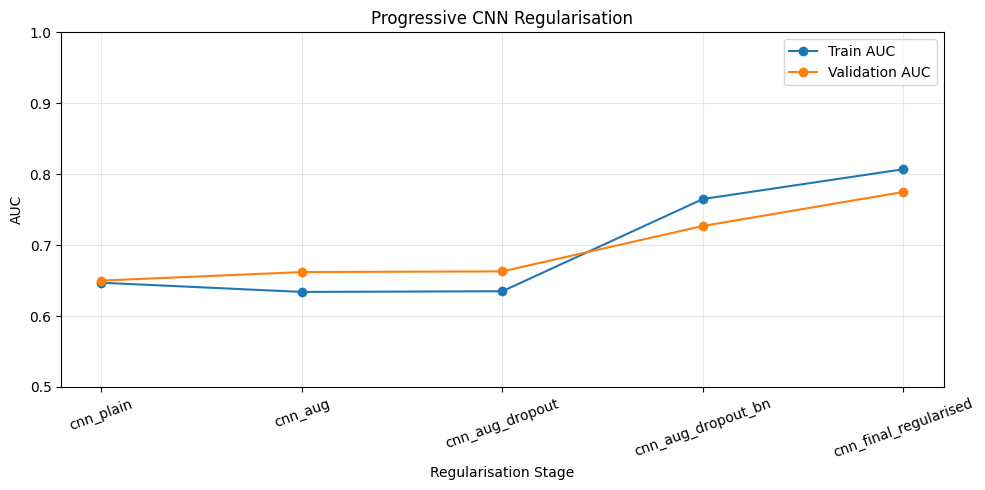

In [19]:
# Plot training and validation AUC across regularisation stages
plt.figure(figsize=(10, 5))
plt.plot(succession_df['Stage'], succession_df['Train AUC'], marker='o', label='Train AUC')
plt.plot(succession_df['Stage'], succession_df['Val AUC'], marker='o', label='Validation AUC')
plt.xlabel('Regularisation Stage')
plt.ylabel('AUC')
plt.title('Progressive CNN Regularisation')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Regularisation Interpretation

Regularisation produced a substantially larger improvement than network scaling. Validation AUC increased from 0.650 for the plain CNN to 0.775 for the fully regularised model. Augmentation and dropout alone produced only small AUC gains and poor malignant-case sensitivity at the default threshold, while the largest improvement occurred after batch normalisation and L2 regularisation were introduced.

## 4.1 Final Regularised CNN — Validation Evaluation
Evaluates the final from-scratch CNN on the validation set. These results are used later for model comparison and selection; the held-out test set is not used at this stage.

In [20]:
# Final regularised CNN - Validation evaluation
# Used for model comparison/selection
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

val_loss_cnn, val_acc_cnn, val_auc_cnn = model.evaluate(
    val_ds,
    verbose=0
)

print(
    f"[Final Regularised CNN] "
    f"Val accuracy: {val_acc_cnn:.3f}, "
    f"Val AUC: {val_auc_cnn:.3f}"
)

y_true_val_cnn = val_df['label'].values

y_pred_prob_val_cnn = model.predict(
    val_ds,
    verbose=0
).flatten()

y_pred_val_cnn = (
    y_pred_prob_val_cnn >= 0.5
).astype(int)

print(
    classification_report(
        y_true_val_cnn,
        y_pred_val_cnn,
        target_names=['Benign', 'Malignant']
    )
)

print("Confusion matrix (validation):")
print(
    confusion_matrix(
        y_true_val_cnn,
        y_pred_val_cnn
    )
)

fpr_val_cnn, tpr_val_cnn, _ = roc_curve(
    y_true_val_cnn,
    y_pred_prob_val_cnn
)

roc_auc_val_cnn = auc(
    fpr_val_cnn,
    tpr_val_cnn
)

print(
    f"[Final Regularised CNN] "
    f"Validation ROC AUC: {roc_auc_val_cnn:.3f}"
)

[Final Regularised CNN] Val accuracy: 0.701, Val AUC: 0.776
              precision    recall  f1-score   support

      Benign       0.69      0.77      0.73       176
   Malignant       0.71      0.62      0.66       158

    accuracy                           0.70       334
   macro avg       0.70      0.70      0.70       334
weighted avg       0.70      0.70      0.70       334

Confusion matrix (validation):
[[136  40]
 [ 60  98]]
[Final Regularised CNN] Validation ROC AUC: 0.775


## 4.2 Final CNN Training Curves
Plots training and validation loss and AUC across epochs to assess learning behaviour and potential overfitting.

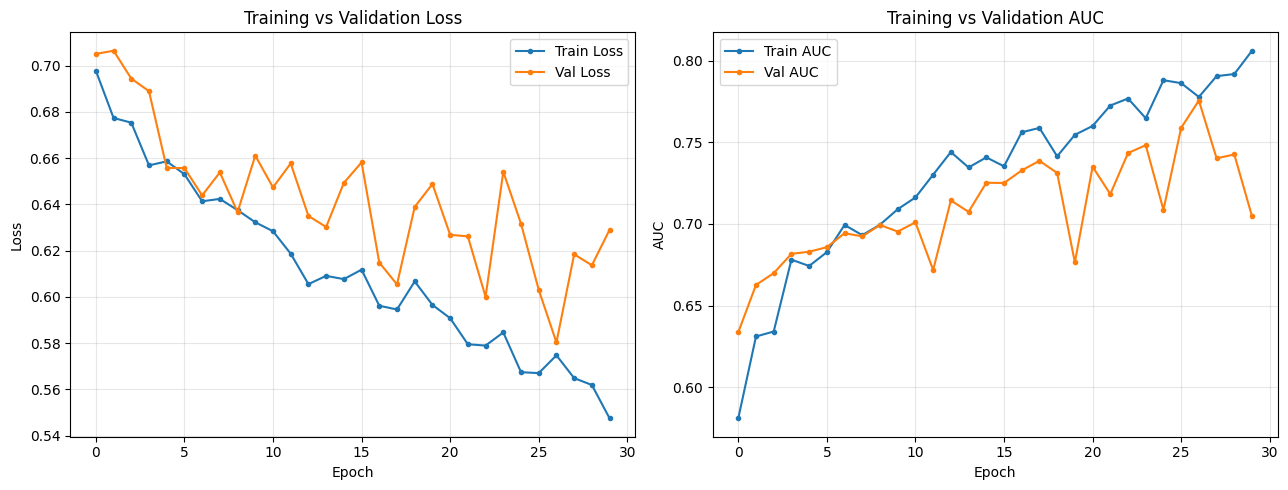

In [21]:
# Training vs validation loss and AUC across epochs
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history['loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['auc'], label='Train AUC', marker='o', markersize=3)
axes[1].plot(history['val_auc'], label='Val AUC', marker='o', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Training vs Validation AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Transfer Learning — VGG16
Evaluates whether transfer learning with an ImageNet-pretrained VGG16 backbone improves mammogram classification compared with the CNN trained from scratch.

## 5.1 VGG16 Input Pipeline
Builds the VGG16 preprocessing and augmentation pipeline.

In [22]:
# Build the shared transfer-learning input pipeline
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Step 1: Read and resize the mammogram
def load_and_resize_transfer(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(
        img,
        channels=1
    )

    img = tf.image.resize(
        img,
        [IMG_SIZE, IMG_SIZE]
    )

    return img, label

def make_transfer_dataset(
    df,
    cache_name,
    preprocess_fn,
    shuffle=False,
    augment=False
):

    paths = df['real_path'].values
    labels = df['label'].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_and_resize_transfer,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Cache before augmentation/preprocessing
    cache_path = os.path.join(
        CACHE_DIR,
        cache_name
    )

    ds = ds.cache(cache_path)

    # Training augmentation
    if augment:

        def aug(img, label):

            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(
                img,
                max_delta=25.5
            )

            img = tf.clip_by_value(
                img,
                0.0,
                255.0
            )

            return img, label

        ds = ds.map(
            aug,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Convert grayscale to rgb
    # Apply model preprocessing
    def prepare_for_model(img, label):

        img = tf.image.grayscale_to_rgb(img)

        img = preprocess_fn(img)

        return img, label

    ds = ds.map(
        prepare_for_model,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:

        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds

# VGG16 datasets
train_ds_vgg = make_transfer_dataset(
    train_df,
    cache_name="transfer_train_cache",
    preprocess_fn=vgg_preprocess,
    shuffle=True,
    augment=True
)

val_ds_vgg = make_transfer_dataset(
    val_df,
    cache_name="transfer_val_cache",
    preprocess_fn=vgg_preprocess
)

test_ds_vgg = make_transfer_dataset(
    test_df,
    cache_name="transfer_test_cache",
    preprocess_fn=vgg_preprocess
)

print("VGG16 datasets configured.")

VGG16 datasets configured.


## 5.2 VGG16 Frozen-Backbone Training
Trains a new classification head while keeping the VGG16 backbone frozen.

In [23]:
# Stage 1: Frozen VGG16 + new classifier head
from tensorflow.keras.applications import VGG16

def build_vgg_frozen():
    base_model_vgg = VGG16(weights='imagenet', include_top=False,
                            input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model_vgg.trainable = False
    m = models.Sequential([
        base_model_vgg,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

vgg_model, _ = train_or_load(build_vgg_frozen, "vgg16_frozen",
                              train_ds_vgg, val_ds_vgg, epochs=30, patience=5)
vgg_model.summary()

[vgg16_frozen] already trained -> loading from Drive, no retraining


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,813,381 (56.51 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 65,796 (257.02 KB)

## 5.3 VGG16 Fine-Tuning
Fine-tunes VGG16 `block5` using a reduced learning rate.

In [24]:
# Stage 2: Unfreeze block5, fine-tune from Stage 1 weights
def build_vgg_finetune():
    m = tf.keras.models.load_model(os.path.join(MODEL_DIR, "vgg16_frozen_best.keras"))
    base = m.layers[0]
    base.trainable = True
    for layer in base.layers:
        if not layer.name.startswith('block5'):
            layer.trainable = False
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

vgg_model, vgg_finetune_history = train_or_load(
    build_vgg_finetune,
    "vgg16_finetuned",
    train_ds_vgg,
    val_ds_vgg,
    epochs=15,
    patience=5
)

[vgg16_finetuned] already trained -> loading from Drive, no retraining


## 5.4 VGG16 Fine-Tuning Curves

Plots training and validation AUC and loss during VGG16 fine-tuning.

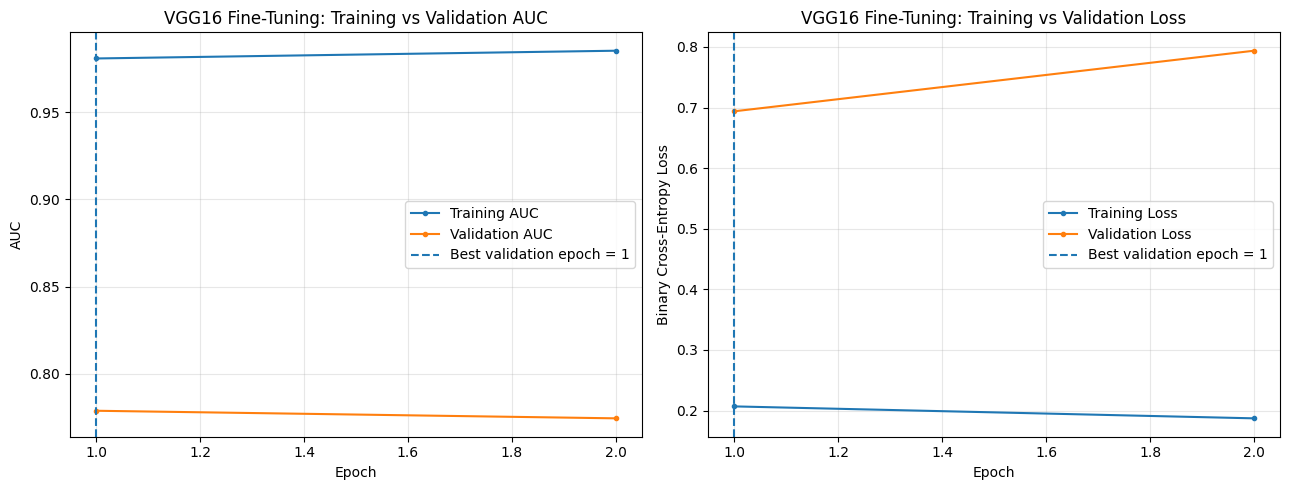

Best VGG16 validation-AUC epoch: 1
Best validation AUC: 0.779
Training AUC at that epoch: 0.981


In [25]:
# VGG16 Fine-tuning curves
import matplotlib.pyplot as plt
import numpy as np

best_vgg_epoch = np.argmax(vgg_finetune_history['val_auc']) + 1
epochs_vgg = range(1, len(vgg_finetune_history['auc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC
axes[0].plot(
    epochs_vgg,
    vgg_finetune_history['auc'],
    label='Training AUC',
    marker='o',
    markersize=3
)

axes[0].plot(
    epochs_vgg,
    vgg_finetune_history['val_auc'],
    label='Validation AUC',
    marker='o',
    markersize=3
)

axes[0].axvline(
    best_vgg_epoch,
    linestyle='--',
    label=f'Best validation epoch = {best_vgg_epoch}'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].set_title('VGG16 Fine-Tuning: Training vs Validation AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    epochs_vgg,
    vgg_finetune_history['loss'],
    label='Training Loss',
    marker='o',
    markersize=3
)

axes[1].plot(
    epochs_vgg,
    vgg_finetune_history['val_loss'],
    label='Validation Loss',
    marker='o',
    markersize=3
)

axes[1].axvline(
    best_vgg_epoch,
    linestyle='--',
    label=f'Best validation epoch = {best_vgg_epoch}'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].set_title('VGG16 Fine-Tuning: Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best VGG16 validation-AUC epoch: {best_vgg_epoch}")
print(
    f"Best validation AUC: "
    f"{vgg_finetune_history['val_auc'][best_vgg_epoch - 1]:.3f}"
)
print(
    f"Training AUC at that epoch: "
    f"{vgg_finetune_history['auc'][best_vgg_epoch - 1]:.3f}"
)

## 5.5 VGG16 Validation Evaluation
Evaluates fine-tuned VGG16 on the validation set.

In [26]:
# Validation evaluation for fine-tuned VGG16 (comparison)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

val_loss_vgg, val_acc_vgg, val_auc_vgg = vgg_model.evaluate(val_ds_vgg)
print(f"[VGG16] Val accuracy: {val_acc_vgg:.3f}, Val AUC: {val_auc_vgg:.3f}")

y_true_val_vgg = val_df['label'].values
y_pred_prob_val_vgg = vgg_model.predict(val_ds_vgg).flatten()
y_pred_val_vgg = (y_pred_prob_val_vgg >= 0.5).astype(int)

print(classification_report(y_true_val_vgg, y_pred_val_vgg, target_names=['Benign', 'Malignant']))
print("Confusion matrix (validation):")
print(confusion_matrix(y_true_val_vgg, y_pred_val_vgg))

fpr_val_vgg, tpr_val_vgg, _ = roc_curve(y_true_val_vgg, y_pred_prob_val_vgg)
roc_auc_val_vgg = auc(fpr_val_vgg, tpr_val_vgg)
print(f"[VGG16] Validation ROC AUC: {roc_auc_val_vgg:.3f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 757ms/step - accuracy: 0.6946 - auc: 0.7788 - loss: 0.6938
[VGG16] Val accuracy: 0.695, Val AUC: 0.779
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step
              precision    recall  f1-score   support

      Benign       0.68      0.81      0.74       176
   Malignant       0.73      0.57      0.64       158

    accuracy                           0.69       334
   macro avg       0.70      0.69      0.69       334
weighted avg       0.70      0.69      0.69       334

Confusion matrix (validation):
[[142  34]
 [ 68  90]]
[VGG16] Validation ROC AUC: 0.779


# 6. Transfer Learning — ResNet50
Evaluates ImageNet-pretrained ResNet50 using the same data split and metrics.

## 6.1 ResNet50 Input Pipeline
Applies ResNet50-specific preprocessing through the shared transfer-learning pipeline.

In [27]:
# ResNet50 Datasets
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

train_ds_resnet = make_transfer_dataset(
    train_df,
    cache_name="transfer_train_cache",
    preprocess_fn=resnet_preprocess,
    shuffle=True,
    augment=True
)

val_ds_resnet = make_transfer_dataset(
    val_df,
    cache_name="transfer_val_cache",
    preprocess_fn=resnet_preprocess
)

test_ds_resnet = make_transfer_dataset(
    test_df,
    cache_name="transfer_test_cache",
    preprocess_fn=resnet_preprocess
)

print("ResNet50 datasets configured.")

ResNet50 datasets configured.


## 6.2 ResNet50 Frozen-Backbone Training
Trains a new classification head while keeping the ResNet50 backbone frozen.

In [28]:
# Stage 1: Frozen ResNet50 + new classifier head
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers

def build_resnet_frozen():
    base_model_resnet = ResNet50(weights='imagenet', include_top=False,
                                  input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model_resnet.trainable = False
    m = models.Sequential([
        base_model_resnet,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

resnet_model, _ = train_or_load(build_resnet_frozen, "resnet50_frozen",
                                 train_ds_resnet, val_ds_resnet, epochs=30, patience=5)
resnet_model.summary()

[resnet50_frozen] already trained -> loading from Drive, no retraining


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,981,317 (91.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 262,404 (1.00 MB)

## 6.3 ResNet50 Fine-Tuning
Fine-tunes `conv5_block` while keeping BatchNorm layers frozen.

In [29]:
# Stage 2: Unfreeze conv5_block, fine-tune from Stage 1 weights
def build_resnet_finetune():
    m = tf.keras.models.load_model(os.path.join(MODEL_DIR, "resnet50_frozen_best.keras"))
    base = m.layers[0]
    base.trainable = True
    for layer in base.layers:
        if not layer.name.startswith('conv5_block'):
            layer.trainable = False
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return m

resnet_model, resnet_finetune_history = train_or_load(
    build_resnet_finetune,
    "resnet50_finetuned",
    train_ds_resnet,
    val_ds_resnet,
    epochs=15,
    patience=5
)

[resnet50_finetuned] already trained -> loading from Drive, no retraining


## 6.4 ResNet50 Fine-Tuning Curves

Plots training and validation AUC and loss during fine-tuning.

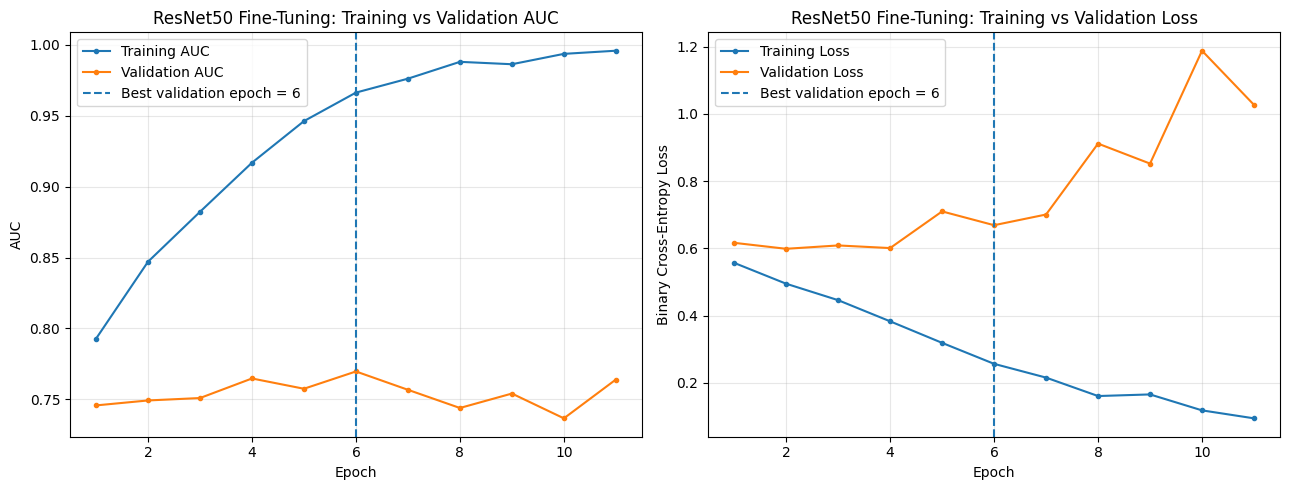

Best ResNet50 validation-AUC epoch: 6
Best validation AUC: 0.770
Training AUC at that epoch: 0.966


In [30]:
# ResNet50 Fine-tuning curves
best_resnet_epoch = np.argmax(resnet_finetune_history['val_auc']) + 1
epochs_resnet = range(1, len(resnet_finetune_history['auc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC
axes[0].plot(
    epochs_resnet,
    resnet_finetune_history['auc'],
    label='Training AUC',
    marker='o',
    markersize=3
)

axes[0].plot(
    epochs_resnet,
    resnet_finetune_history['val_auc'],
    label='Validation AUC',
    marker='o',
    markersize=3
)

axes[0].axvline(
    best_resnet_epoch,
    linestyle='--',
    label=f'Best validation epoch = {best_resnet_epoch}'
)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].set_title('ResNet50 Fine-Tuning: Training vs Validation AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    epochs_resnet,
    resnet_finetune_history['loss'],
    label='Training Loss',
    marker='o',
    markersize=3
)

axes[1].plot(
    epochs_resnet,
    resnet_finetune_history['val_loss'],
    label='Validation Loss',
    marker='o',
    markersize=3
)

axes[1].axvline(
    best_resnet_epoch,
    linestyle='--',
    label=f'Best validation epoch = {best_resnet_epoch}'
)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].set_title('ResNet50 Fine-Tuning: Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best ResNet50 validation-AUC epoch: {best_resnet_epoch}")
print(
    f"Best validation AUC: "
    f"{resnet_finetune_history['val_auc'][best_resnet_epoch - 1]:.3f}"
)
print(
    f"Training AUC at that epoch: "
    f"{resnet_finetune_history['auc'][best_resnet_epoch - 1]:.3f}"
)

## 6.5 ResNet50 Validation Evaluation
Evaluates fine-tuned ResNet50 on the validation set.

In [31]:
# Validation evaluation for fine-tuned ResNet50 (comparison)
val_loss_resnet, val_acc_resnet, val_auc_resnet = resnet_model.evaluate(val_ds_resnet)
print(f"[ResNet50] Val accuracy: {val_acc_resnet:.3f}, Val AUC: {val_auc_resnet:.3f}")

y_true_val_resnet = val_df['label'].values
y_pred_prob_val_resnet = resnet_model.predict(val_ds_resnet).flatten()
y_pred_val_resnet = (y_pred_prob_val_resnet >= 0.5).astype(int)

print(classification_report(y_true_val_resnet, y_pred_val_resnet, target_names=['Benign', 'Malignant']))
print("Confusion matrix (validation):")
print(confusion_matrix(y_true_val_resnet, y_pred_val_resnet))

fpr_val_resnet, tpr_val_resnet, _ = roc_curve(y_true_val_resnet, y_pred_prob_val_resnet)
roc_auc_val_resnet = auc(fpr_val_resnet, tpr_val_resnet)
print(f"[ResNet50] Validation ROC AUC: {roc_auc_val_resnet:.3f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 280ms/step - accuracy: 0.6737 - auc: 0.7697 - loss: 0.6688
[ResNet50] Val accuracy: 0.674, Val AUC: 0.770
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 239ms/step
              precision    recall  f1-score   support

      Benign       0.72      0.62      0.67       176
   Malignant       0.63      0.73      0.68       158

    accuracy                           0.67       334
   macro avg       0.68      0.68      0.67       334
weighted avg       0.68      0.67      0.67       334

Confusion matrix (validation):
[[109  67]
 [ 42 116]]
[ResNet50] Validation ROC AUC: 0.769


# 7. Final Model Selection Using the Validation Set
Compares the final regularised CNN, fine-tuned VGG16 and fine-tuned ResNet50 using validation AUC. The model with the highest validation AUC is selected as the final model without using test-set performance.

In [32]:
# Select the final model using validation AUC only
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def val_metrics_row(name, y_true, y_pred, auc_val, acc_val):
    return {
        'Model': name,
        'Val AUC': auc_val,
        'Val Accuracy': acc_val,
        'Val Precision': precision_score(y_true, y_pred, zero_division=0),
        'Val Sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'Val Specificity': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'Val F1': f1_score(y_true, y_pred, zero_division=0)
    }

comparison_df = pd.DataFrame([
    val_metrics_row('Final Regularised CNN', y_true_val_cnn, y_pred_val_cnn, roc_auc_val_cnn, val_acc_cnn),
    val_metrics_row('VGG16 (fine-tuned)', y_true_val_vgg, y_pred_val_vgg, roc_auc_val_vgg, val_acc_vgg),
    val_metrics_row('ResNet50 (fine-tuned)', y_true_val_resnet, y_pred_val_resnet, roc_auc_val_resnet, val_acc_resnet),
])

comparison_df = comparison_df.sort_values('Val AUC', ascending=False).reset_index(drop=True)

print("=== Validation Model Comparison ===")
print(comparison_df)

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nSelected final model (highest validation AUC): {best_model_name}")

=== Validation Model Comparison ===
                   Model   Val AUC  Val Accuracy  Val Precision  \
0     VGG16 (fine-tuned)  0.779380      0.694611       0.725806   
1  Final Regularised CNN  0.775173      0.700599       0.710145   
2  ResNet50 (fine-tuned)  0.769383      0.673653       0.633880   

   Val Sensitivity  Val Specificity    Val F1  
0         0.569620         0.806818  0.638298  
1         0.620253         0.772727  0.662162  
2         0.734177         0.619318  0.680352  

Selected final model (highest validation AUC): VGG16 (fine-tuned)


### Model-Selection Interpretation

The three final models achieved similar validation AUC values. Fine-tuned VGG16 achieved the highest validation AUC of 0.779 and was therefore selected according to the predefined primary metric, although its advantage over the regularised CNN at 0.775 was only 0.004. This indicates that transfer learning provided only a modest improvement over the strongest from-scratch model.

# 8. Decision Threshold Selection Using the Validation Set
Uses only the selected model's validation predictions to test candidate classification thresholds. Sensitivity, specificity, F1-score and Youden's J are calculated at each threshold, and the threshold with the highest Youden's J is selected and then fixed for final testing.

In [33]:
# Select the operating threshold using validation data only
from sklearn.metrics import recall_score, f1_score

# Stores validation predictions
model_registry = {
    'Final Regularised CNN': {
        'val_probs': y_pred_prob_val_cnn,
        'val_true': y_true_val_cnn
    },

    'VGG16 (fine-tuned)': {
        'val_probs': y_pred_prob_val_vgg,
        'val_true': y_true_val_vgg
    },

    'ResNet50 (fine-tuned)': {
        'val_probs': y_pred_prob_val_resnet,
        'val_true': y_true_val_resnet
    }
}

# Get validation predictions for the selected model
final = model_registry[best_model_name]

print(f"Selected final model: {best_model_name}")

# Threshold sweep - Validation set
threshold_rows = []

for t in np.arange(0.05, 0.96, 0.01):

    preds = (
        final['val_probs'] >= t
    ).astype(int)

    sensitivity = recall_score(
        final['val_true'],
        preds,
        pos_label=1
    )

    specificity = recall_score(
        final['val_true'],
        preds,
        pos_label=0
    )

    f1 = f1_score(
        final['val_true'],
        preds
    )

    youden_j = (
        sensitivity +
        specificity -
        1
    )

    threshold_rows.append({
        'Threshold': round(float(t), 2),
        'Sensitivity': round(sensitivity, 3),
        'Specificity': round(specificity, 3),
        'F1': round(f1, 3),
        'Youden J': round(youden_j, 3)
    })


threshold_df = pd.DataFrame(
    threshold_rows
)

print("\n=== Validation Threshold Sweep ===")
print(threshold_df)

# Select threshold using validation data
best_threshold_idx = threshold_df[
    'Youden J'
].idxmax()

selected_threshold = float(
    threshold_df.loc[
        best_threshold_idx,
        'Threshold'
    ]
)

print(
    f"\nSelected threshold: "
    f"{selected_threshold:.2f}"
)

print(
    "Threshold selected using validation data only "
    "(maximum Youden's J)."
)

Selected final model: VGG16 (fine-tuned)

=== Validation Threshold Sweep ===
    Threshold  Sensitivity  Specificity     F1  Youden J
0        0.05        0.905        0.403  0.704     0.308
1        0.06        0.905        0.426  0.711     0.331
2        0.07        0.892        0.449  0.712     0.341
3        0.08        0.892        0.472  0.719     0.364
4        0.09        0.880        0.489  0.718     0.368
..        ...          ...          ...    ...       ...
86       0.91        0.203        0.989  0.333     0.191
87       0.92        0.190        0.989  0.316     0.179
88       0.93        0.171        0.989  0.289     0.160
89       0.94        0.158        0.989  0.270     0.147
90       0.95        0.146        0.989  0.251     0.134

[91 rows x 5 columns]

Selected threshold: 0.27
Threshold selected using validation data only (maximum Youden's J).


In [34]:
# Youden's J vs Sensitivity-targeted threshold for all models
from sklearn.metrics import recall_score, f1_score

TARGET_SENSITIVITY = 0.75

def sweep_thresholds(val_probs, val_true):
    rows = []
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (val_probs >= t).astype(int)
        sens = recall_score(val_true, preds, pos_label=1, zero_division=0)
        spec = recall_score(val_true, preds, pos_label=0, zero_division=0)
        f1 = f1_score(val_true, preds, zero_division=0)
        rows.append({'Threshold': round(float(t), 2), 'Sensitivity': sens,
                      'Specificity': spec, 'F1': f1, 'Youden J': sens + spec - 1})
    return pd.DataFrame(rows)

dual_threshold_rows = []
for model_name, data in model_registry.items():
    sweep = sweep_thresholds(data['val_probs'], data['val_true'])

    j_row = sweep.loc[sweep['Youden J'].idxmax()]

    candidates = sweep[sweep['Sensitivity'] >= TARGET_SENSITIVITY]
    if len(candidates) > 0:
        s_row = candidates.sort_values('Threshold', ascending=False).iloc[0]
    else:
        s_row = sweep.sort_values('Sensitivity', ascending=False).iloc[0]

    dual_threshold_rows.append({
        'Model': model_name,
        "Youden's J: Threshold": round(j_row['Threshold'], 2),
        "Youden's J: Sensitivity": round(j_row['Sensitivity'], 3),
        "Youden's J: Specificity": round(j_row['Specificity'], 3),
        f"Sens-Target (>={TARGET_SENSITIVITY:.0%}): Threshold": round(s_row['Threshold'], 2),
        "Sens-Target: Sensitivity": round(s_row['Sensitivity'], 3),
        "Sens-Target: Specificity": round(s_row['Specificity'], 3),
    })

dual_threshold_df = pd.DataFrame(dual_threshold_rows)
print("=== Youden's J vs Sensitivity-Targeted Threshold (validation set, all models) ===")
print(dual_threshold_df)
print(f"\nOfficial locked threshold (unchanged): {selected_threshold:.2f}, "
      f"Youden's J, for {best_model_name}.")

=== Youden's J vs Sensitivity-Targeted Threshold (validation set, all models) ===
                   Model  Youden's J: Threshold  Youden's J: Sensitivity  \
0  Final Regularised CNN                   0.49                    0.665   
1     VGG16 (fine-tuned)                   0.27                    0.753   
2  ResNet50 (fine-tuned)                   0.69                    0.614   

   Youden's J: Specificity  Sens-Target (>=75%): Threshold  \
0                    0.761                            0.42   
1                    0.659                            0.27   
2                    0.778                            0.47   

   Sens-Target: Sensitivity  Sens-Target: Specificity  
0                     0.753                     0.597  
1                     0.753                     0.659  
2                     0.753                     0.614  

Official locked threshold (unchanged): 0.27, Youden's J, for VGG16 (fine-tuned).


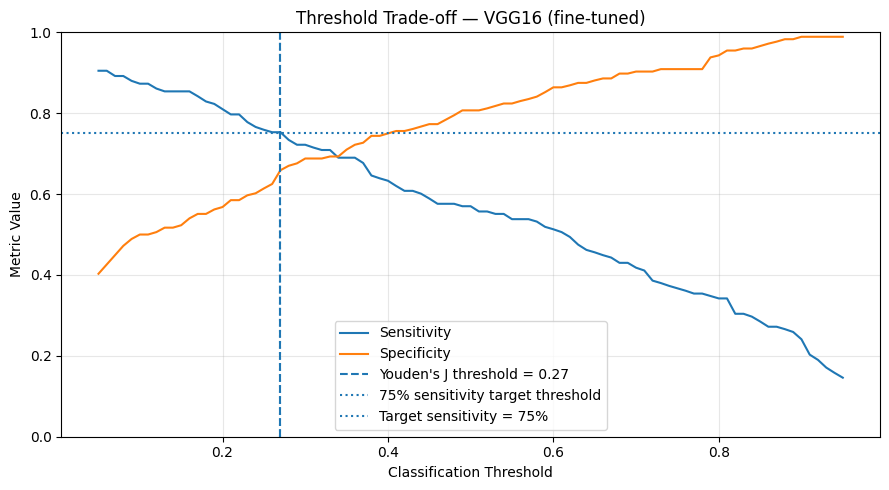

In [35]:
# Visualise the sensitivity-specificity trade-off across thresholds
sens_target_threshold_viz = dual_threshold_df.loc[
    dual_threshold_df['Model'] == best_model_name,
    f"Sens-Target (>={TARGET_SENSITIVITY:.0%}): Threshold"
].values[0]

plt.figure(figsize=(9, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Sensitivity'], label='Sensitivity')
plt.plot(threshold_df['Threshold'], threshold_df['Specificity'], label='Specificity')
plt.axvline(selected_threshold, linestyle='--',
            label=f"Youden's J threshold = {selected_threshold:.2f}")
plt.axvline(sens_target_threshold_viz, linestyle=':',
            label=f'{TARGET_SENSITIVITY:.0%} sensitivity target threshold')
plt.axhline(TARGET_SENSITIVITY, linestyle=':',
            label=f'Target sensitivity = {TARGET_SENSITIVITY:.0%}')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title(f'Threshold Trade-off — {best_model_name}')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Interpretation

The validation-selected threshold of 0.27 increased malignant-case sensitivity compared with the default 0.5 threshold, while reducing specificity. This illustrates the operating-point trade-off introduced by threshold selection. The threshold is therefore treated as a reproducible experimental operating point rather than a clinically validated decision boundary.

# 9. Final Locked Evaluation on the Held-Out Test Set
Evaluates the final model on previously unseen test patients using the model selected by validation AUC and the decision threshold selected on the validation set. Neither the model nor the threshold is changed after viewing test performance.

In [36]:
# Apply the locked model and threshold to the held-out test set
final_model_lookup = {
    'Final Regularised CNN':  (model,        test_ds,        test_df['label'].values),
    'VGG16 (fine-tuned)':     (vgg_model,     test_ds_vgg,    test_df['label'].values),
    'ResNet50 (fine-tuned)':  (resnet_model,  test_ds_resnet, test_df['label'].values),
}

final_test_model, final_test_ds, y_true_final = final_model_lookup[best_model_name]

y_pred_prob_final = final_test_model.predict(final_test_ds).flatten()
y_pred_final = (y_pred_prob_final >= selected_threshold).astype(int)

print(f"FINAL MODEL: {best_model_name}")
print(f"Threshold used: {selected_threshold:.2f} (selected on validation data only)\n")

print(classification_report(y_true_final, y_pred_final, target_names=['Benign', 'Malignant']))
print("Confusion matrix:")
print(confusion_matrix(y_true_final, y_pred_final))

fpr_final, tpr_final, _ = roc_curve(y_true_final, y_pred_prob_final)
final_auc = auc(fpr_final, tpr_final)
print(f"\nFinal Test AUC ({best_model_name}): {final_auc:.3f}")
print("(AUC itself does not depend on the threshold -- it is the same number")
print(" already reported in this model's test-evaluation cell above. The")
print(" threshold only changes which cases get called malignant vs benign.)")

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step
FINAL MODEL: VGG16 (fine-tuned)
Threshold used: 0.27 (selected on validation data only)

              precision    recall  f1-score   support

      Benign       0.76      0.62      0.68       381
   Malignant       0.57      0.72      0.64       264

    accuracy                           0.66       645
   macro avg       0.67      0.67      0.66       645
weighted avg       0.68      0.66      0.66       645

Confusion matrix:
[[237 144]
 [ 74 190]]

Final Test AUC (VGG16 (fine-tuned)): 0.741
(AUC itself does not depend on the threshold -- it is the same number
 already reported in this model's test-evaluation cell above. The
 threshold only changes which cases get called malignant vs benign.)


In [37]:
# Supplementary: Sensitivity-targeted operating point on test
from sklearn.metrics import accuracy_score

sens_target_threshold = dual_threshold_df.loc[
    dual_threshold_df['Model'] == best_model_name,
    f"Sens-Target (>={TARGET_SENSITIVITY:.0%}): Threshold"
].values[0]

y_pred_sens_target = (y_pred_prob_final >= sens_target_threshold).astype(int)

print(f"=== {best_model_name}: Youden's J vs Sensitivity-Targeted, TEST SET ===")
print(f"{'Metric':<14}{'Youden J @ ' + str(selected_threshold):<22}"
      f"{'Sens-Target @ ' + str(sens_target_threshold)}")
print(f"{'Sensitivity':<14}"
      f"{recall_score(y_true_final, y_pred_final):<22.3f}"
      f"{recall_score(y_true_final, y_pred_sens_target):.3f}")
print(f"{'Specificity':<14}"
      f"{recall_score(y_true_final, y_pred_final, pos_label=0):<22.3f}"
      f"{recall_score(y_true_final, y_pred_sens_target, pos_label=0):.3f}")
print(f"{'Accuracy':<14}"
      f"{accuracy_score(y_true_final, y_pred_final):<22.3f}"
      f"{accuracy_score(y_true_final, y_pred_sens_target):.3f}")
print("\nBoth reported for discussion; the AUC and Youden's-J-thresholded")
print("result above remains the project's single official test result.")

=== VGG16 (fine-tuned): Youden's J vs Sensitivity-Targeted, TEST SET ===
Metric        Youden J @ 0.27       Sens-Target @ 0.27
Sensitivity   0.720                 0.720
Specificity   0.622                 0.622
Accuracy      0.662                 0.662

Both reported for discussion; the AUC and Youden's-J-thresholded
result above remains the project's single official test result.


In [38]:
# Naive baseline - held-out test set
naive_test_predictions = np.full(len(test_df), majority_class)
naive_test_scores = np.full(len(test_df), float(majority_class))

naive_test_accuracy = accuracy_score(test_df['label'], naive_test_predictions)
naive_test_auc = roc_auc_score(test_df['label'], naive_test_scores)

print("\nNAIVE TEST BASELINE")
print("Accuracy:", round(naive_test_accuracy, 3))
print("AUC:", round(naive_test_auc, 3))


NAIVE TEST BASELINE
Accuracy: 0.591
AUC: 0.5


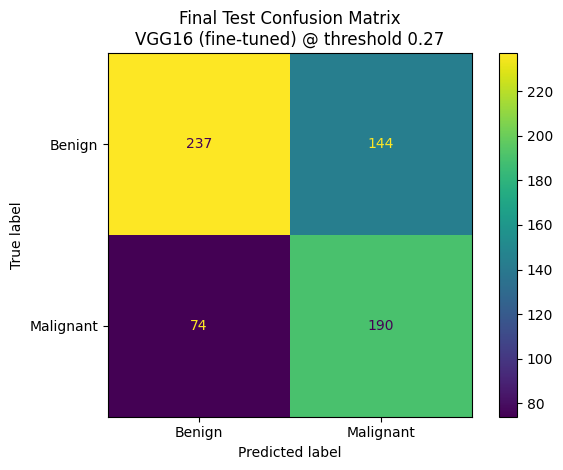

In [39]:
# Plot the final confusion matrix at the locked validation-selected threshold
from sklearn.metrics import ConfusionMatrixDisplay

cm_final = confusion_matrix(y_true_final, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Benign', 'Malignant'])
disp.plot(values_format='d')
plt.title(f'Final Test Confusion Matrix\n{best_model_name} @ threshold {selected_threshold:.2f}')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/fig_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

In [40]:
# Estimate 95% CIs using patient-level bootstrap resampling
rng = np.random.default_rng(SEED)

test_patient_ids = test_df['patient_id'].to_numpy()
unique_test_patients = np.unique(test_patient_ids)

N_BOOTSTRAPS = 1000
bootstrap_auc, bootstrap_sensitivity, bootstrap_specificity = [], [], []

for _ in range(N_BOOTSTRAPS):
    sampled_patients = rng.choice(unique_test_patients, size=len(unique_test_patients), replace=True)
    sampled_indices = np.concatenate([
        np.where(test_patient_ids == patient)[0] for patient in sampled_patients
    ])

    y_boot = y_true_final[sampled_indices]
    prob_boot = y_pred_prob_final[sampled_indices]

    if len(np.unique(y_boot)) < 2:
        continue

    pred_boot = (prob_boot >= selected_threshold).astype(int)

    bootstrap_auc.append(roc_auc_score(y_boot, prob_boot))
    bootstrap_sensitivity.append(recall_score(y_boot, pred_boot, pos_label=1, zero_division=0))
    bootstrap_specificity.append(recall_score(y_boot, pred_boot, pos_label=0, zero_division=0))

def bootstrap_ci(values):
    return np.percentile(values, [2.5, 97.5])

auc_ci = bootstrap_ci(bootstrap_auc)
sens_ci = bootstrap_ci(bootstrap_sensitivity)
spec_ci = bootstrap_ci(bootstrap_specificity)

final_sensitivity = recall_score(y_true_final, y_pred_final, pos_label=1)
final_specificity = recall_score(y_true_final, y_pred_final, pos_label=0)

print("=== Final Model: 95% Patient-Level Bootstrap CIs ===")
print(f"AUC: {final_auc:.3f} (95% CI {auc_ci[0]:.3f}–{auc_ci[1]:.3f})")
print(f"Sensitivity: {final_sensitivity:.3f} (95% CI {sens_ci[0]:.3f}–{sens_ci[1]:.3f})")
print(f"Specificity: {final_specificity:.3f} (95% CI {spec_ci[0]:.3f}–{spec_ci[1]:.3f})")

# Contextual comparison with screening mammography benchmarks
specialist_comparison_df = pd.DataFrame({
    'Metric': ['Sensitivity', 'Specificity'],
    'Final DL Model': [round(final_sensitivity, 3), round(final_specificity, 3)],
    'ACR Screening Mammography Reference': ['>= 0.75', '0.88–0.95']
})

print("\n=== Contextual Comparison with Screening Mammography Benchmarks ===")
print(specialist_comparison_df)
print("\nNOTE: This is a contextual comparison only. The ACR values come from "
      "clinical screening practice and are not a head-to-head evaluation on CBIS-DDSM.")

=== Final Model: 95% Patient-Level Bootstrap CIs ===
AUC: 0.741 (95% CI 0.697–0.788)
Sensitivity: 0.720 (95% CI 0.663–0.779)
Specificity: 0.622 (95% CI 0.567–0.682)

=== Contextual Comparison with Screening Mammography Benchmarks ===
        Metric  Final DL Model ACR Screening Mammography Reference
0  Sensitivity           0.720                             >= 0.75
1  Specificity           0.622                           0.88–0.95

NOTE: This is a contextual comparison only. The ACR values come from clinical screening practice and are not a head-to-head evaluation on CBIS-DDSM.


### Final Test Interpretation

The locked VGG16 model achieved a held-out test AUC of 0.741, with sensitivity of 0.720 and specificity of 0.622 at the validation-selected threshold. Performance was lower than on the validation set, and the patient-level bootstrap confidence intervals indicate meaningful uncertainty. The result demonstrates useful discrimination but is not sufficient to support clinical deployment.

## 9.1 Supplementary Held-Out Test Evaluation — VGG16
Reports VGG16 test-set performance for comparison. The default 0.5 threshold results are supplementary; final operating-point results use the validation-selected threshold in Section 9.

In [41]:
# Evaluate fine-tuned VGG16 model on the held-out test set
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

test_loss_vgg, test_acc_vgg, test_auc_vgg = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 (fine-tuned) -- Test accuracy: {test_acc_vgg:.3f}, Test AUC: {test_auc_vgg:.3f}")

y_true_vgg = test_df['label'].values          # true labels, same as baseline
y_pred_prob_vgg = vgg_model.predict(test_ds_vgg).flatten()   # model's predicted probabilities
y_pred_vgg = (y_pred_prob_vgg >= 0.5).astype(int)  # convert probability -> yes/no at 0.5 cutoff

print(classification_report(y_true_vgg, y_pred_vgg, target_names=['Benign', 'Malignant']))
print("Confusion matrix:\n", confusion_matrix(y_true_vgg, y_pred_vgg))

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - accuracy: 0.6899 - auc: 0.7410 - loss: 0.7061
VGG16 (fine-tuned) -- Test accuracy: 0.690, Test AUC: 0.741
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step
              precision    recall  f1-score   support

      Benign       0.71      0.79      0.75       381
   Malignant       0.64      0.54      0.59       264

    accuracy                           0.69       645
   macro avg       0.68      0.67      0.67       645
weighted avg       0.69      0.69      0.68       645

Confusion matrix:
 [[302  79]
 [121 143]]


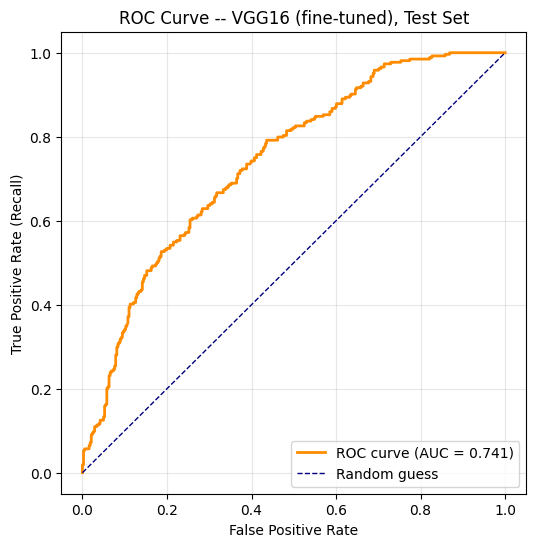

ROC AUC (VGG16 fine-tuned): 0.741


In [42]:
# ROC curve for fine-tuned VGG16 model on the test set
fpr_vgg, tpr_vgg, thresholds_vgg = roc_curve(y_true_vgg, y_pred_prob_vgg)
roc_auc_vgg = auc(fpr_vgg, tpr_vgg)

plt.figure(figsize=(6, 6))
plt.plot(fpr_vgg, tpr_vgg, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_vgg:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve -- VGG16 (fine-tuned), Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curve_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC (VGG16 fine-tuned): {roc_auc_vgg:.3f}")

## 9.2 Supplementary Held-Out Test Evaluation — ResNet50
Reports ResNet50 test-set performance for comparison. The default 0.5 threshold results are supplementary to the final locked evaluation.

In [43]:
# Evaluate fine-tuned ResNet50 model on the held-out test set
test_loss_resnet, test_acc_resnet, test_auc_resnet = resnet_model.evaluate(test_ds_resnet)
print(f"ResNet50 (fine-tuned) -- Test accuracy: {test_acc_resnet:.3f}, Test AUC: {test_auc_resnet:.3f}")

y_true_resnet = test_df['label'].values
y_pred_prob_resnet = resnet_model.predict(test_ds_resnet).flatten()
y_pred_resnet = (y_pred_prob_resnet >= 0.5).astype(int)

print(classification_report(y_true_resnet, y_pred_resnet, target_names=['Benign', 'Malignant']))
print("Confusion matrix:\n", confusion_matrix(y_true_resnet, y_pred_resnet))

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.6450 - auc: 0.7082 - loss: 0.8009
ResNet50 (fine-tuned) -- Test accuracy: 0.645, Test AUC: 0.708
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step
              precision    recall  f1-score   support

      Benign       0.76      0.59      0.66       381
   Malignant       0.55      0.73      0.63       264

    accuracy                           0.64       645
   macro avg       0.65      0.66      0.64       645
weighted avg       0.67      0.64      0.65       645

Confusion matrix:
 [[224 157]
 [ 72 192]]


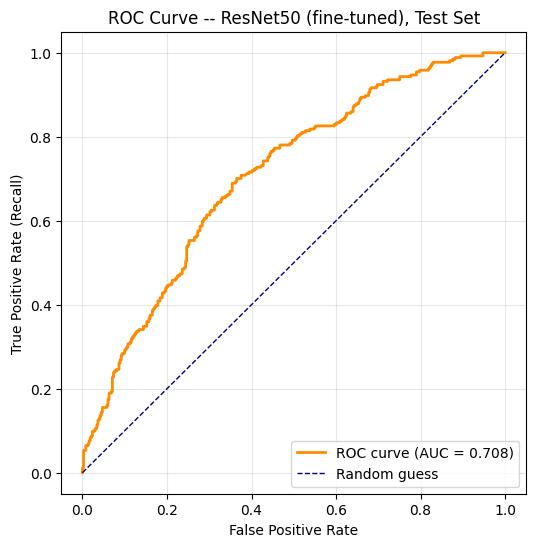

ROC AUC (ResNet50 fine-tuned): 0.708


In [44]:
# Plot the ResNet50 held-out test ROC curve
fpr_resnet, tpr_resnet, _ = roc_curve(y_true_resnet, y_pred_prob_resnet)
roc_auc_resnet = auc(fpr_resnet, tpr_resnet)

plt.figure(figsize=(6, 6))
plt.plot(fpr_resnet, tpr_resnet, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_resnet:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve -- ResNet50 (fine-tuned), Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curve_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC (ResNet50 fine-tuned): {roc_auc_resnet:.3f}")

## 9.3 Supplementary Held-Out Test Evaluation — Final Regularised CNN
Reports the from-scratch CNN's held-out test performance at the default 0.5 classification threshold and generates its ROC curve for comparison with the transfer-learning models.

In [45]:
# Evaluate on the held-out test set
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}, Test AUC: {test_auc:.3f}")


41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.6465 - auc: 0.7000 - loss: 0.6231
Test accuracy: 0.647, Test AUC: 0.700


In [46]:
# Generate raw predicted probabilities and threshold them at 0.5 for hard labels
y_true = test_df['label'].values
y_pred_prob = model.predict(test_ds).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print(y_pred_prob[:10])  # sanity check it ran

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
[0.5859042  0.41959876 0.73542494 0.10109445 0.593861   0.5974528
 0.2842295  0.6531731  0.52988786 0.49149716]


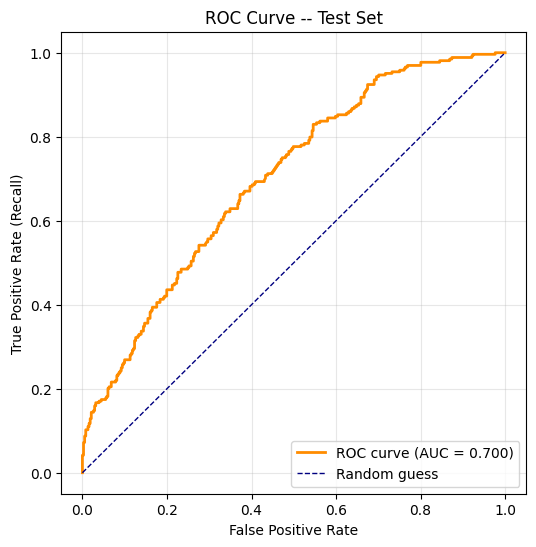

ROC AUC: 0.700


In [47]:
# ROC curve on the held-out test set
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve -- Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")

## 9.4 Held-Out Test ROC Comparison
Compares the threshold-independent ROC curves and AUC values of the final regularised CNN, fine-tuned VGG16 and fine-tuned ResNet50 on the same held-out test set.

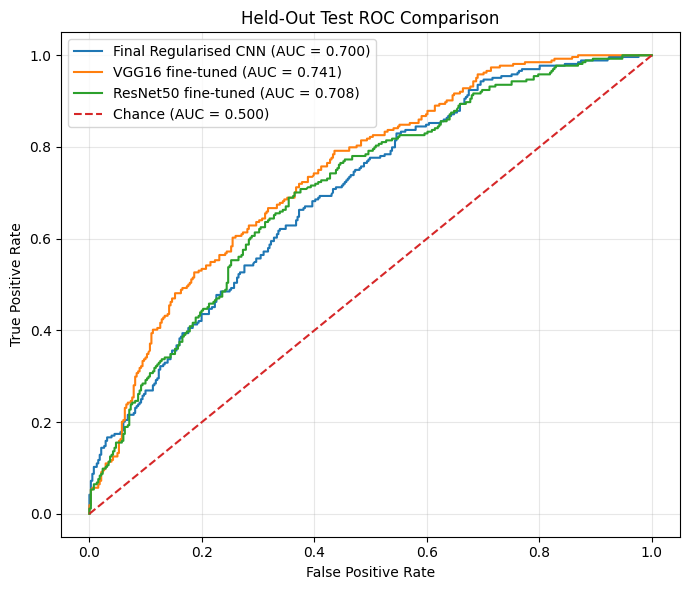

In [48]:
# Held-out test ROC comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Final Regularised CNN (AUC = {roc_auc:.3f})'
)

plt.plot(
    fpr_vgg,
    tpr_vgg,
    label=f'VGG16 fine-tuned (AUC = {roc_auc_vgg:.3f})'
)

plt.plot(
    fpr_resnet,
    tpr_resnet,
    label=f'ResNet50 fine-tuned (AUC = {roc_auc_resnet:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Chance (AUC = 0.500)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Held-Out Test ROC Comparison')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/fig_roc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
plt.show()

In [49]:
# Supplementary test-set summary - All three models at 0.5
test_summary_df = pd.DataFrame({
    'Model': ['Final Regularised CNN', 'VGG16 (fine-tuned)', 'ResNet50 (fine-tuned)'],
    'Test AUC': [roc_auc, roc_auc_vgg, roc_auc_resnet],
    'Test Accuracy (@0.5)': [test_acc, test_acc_vgg, test_acc_resnet],
    'Test Sensitivity (@0.5)': [
        recall_score(y_true, y_pred),
        recall_score(y_true_vgg, y_pred_vgg),
        recall_score(y_true_resnet, y_pred_resnet)
    ],
    'Test Specificity (@0.5)': [
        recall_score(y_true, y_pred, pos_label=0),
        recall_score(y_true_vgg, y_pred_vgg, pos_label=0),
        recall_score(y_true_resnet, y_pred_resnet, pos_label=0)
    ],
})

print("=== Supplementary Test-Set Summary (all @ 0.5 threshold) ===")
print(test_summary_df)
print(f"\nOfficial locked result: {best_model_name} @ threshold {selected_threshold:.2f}")
print(f"-> Test AUC {final_auc:.3f} (reported in Section 9)")

=== Supplementary Test-Set Summary (all @ 0.5 threshold) ===
                   Model  Test AUC  Test Accuracy (@0.5)  \
0  Final Regularised CNN  0.700091              0.646512   
1     VGG16 (fine-tuned)  0.741231              0.689922   
2  ResNet50 (fine-tuned)  0.707906              0.644961   

   Test Sensitivity (@0.5)  Test Specificity (@0.5)  
0                 0.541667                 0.719160  
1                 0.541667                 0.792651  
2                 0.727273                 0.587927  

Official locked result: VGG16 (fine-tuned) @ threshold 0.27
-> Test AUC 0.741 (reported in Section 9)


## 9.5 Detailed CNN Test Metrics at the Default 0.5 Threshold
Reports precision, recall, F1-score and the confusion matrix for the final regularised CNN using the default 0.5 threshold. These metrics are supplementary to the locked final-model evaluation above.

In [50]:
# Report detailed held-out metrics for the final regularised CNN
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))


              precision    recall  f1-score   support

      Benign       0.69      0.72      0.71       381
   Malignant       0.57      0.54      0.56       264

    accuracy                           0.65       645
   macro avg       0.63      0.63      0.63       645
weighted avg       0.64      0.65      0.64       645

Confusion matrix:
[[274 107]
 [121 143]]


## 9.6 Qualitative Prediction Examples
Displays example held-out mammograms together with their true labels, predicted labels and predicted malignancy probabilities to provide a qualitative view of model behaviour.

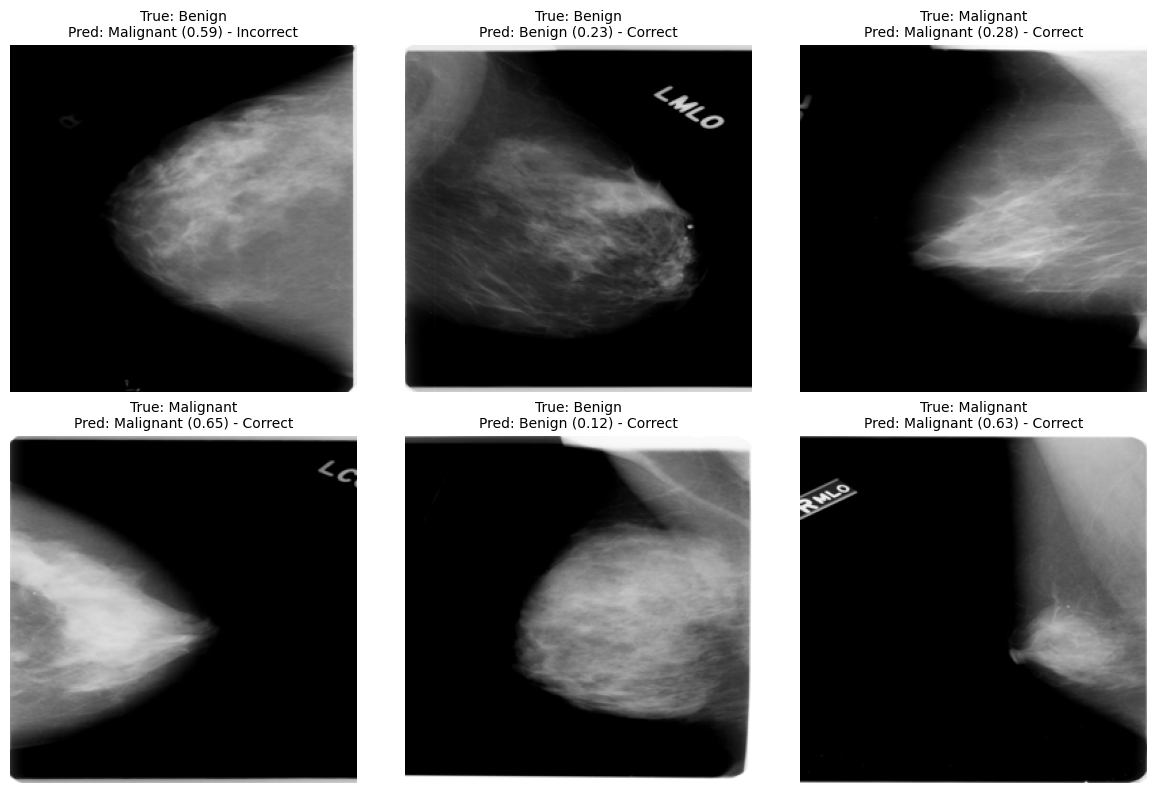

In [51]:
# Qualitative examples from the locked final model
import matplotlib.pyplot as plt

n_show = 6
sample_idx = np.random.choice(len(test_df), n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flatten(), sample_idx):
    img_path = test_df['real_path'].iloc[idx]
    img = Image.open(img_path).resize((256, 256))
    true_label = 'Malignant' if test_df['label'].iloc[idx] == 1 else 'Benign'
    pred_prob = y_pred_prob_final[idx]
    pred_label = 'Malignant' if pred_prob >= selected_threshold else 'Benign'

    ax.imshow(img, cmap='gray')
    correct = 'Correct' if pred_label == true_label else 'Incorrect'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({pred_prob:.2f}) - {correct}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

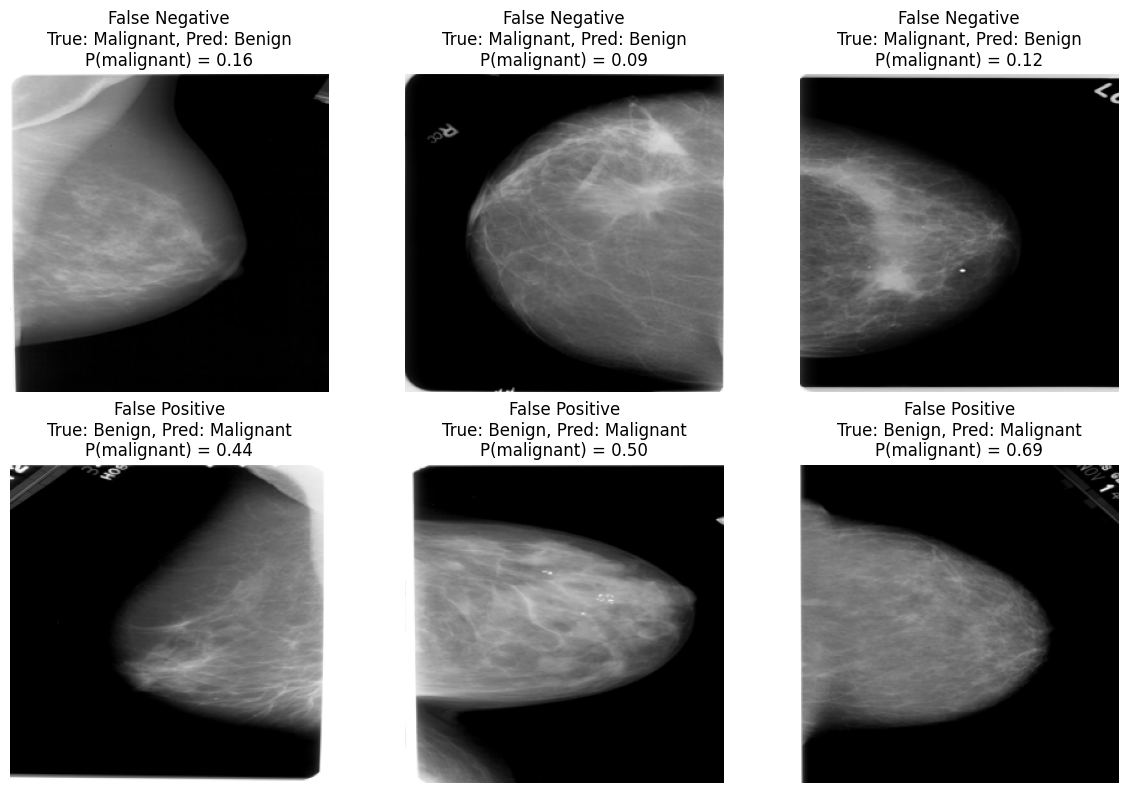

In [52]:
# Display representative false-negative and false-positive cases
false_negative_idx = np.where((y_true_final == 1) & (y_pred_final == 0))[0]
false_positive_idx = np.where((y_true_final == 0) & (y_pred_final == 1))[0]

fn_show = false_negative_idx[:3]
fp_show = false_positive_idx[:3]
example_indices = np.concatenate([fn_show, fp_show])

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flatten(), example_indices):
    img_path = test_df['real_path'].iloc[idx]
    img = Image.open(img_path).resize((256, 256))

    true_label = 'Malignant' if y_true_final[idx] == 1 else 'Benign'
    pred_label = 'Malignant' if y_pred_final[idx] == 1 else 'Benign'
    error_type = 'False Negative' if y_true_final[idx] == 1 else 'False Positive'

    ax.imshow(img, cmap='gray')
    ax.set_title(f'{error_type}\nTrue: {true_label}, Pred: {pred_label}\n'
                 f'P(malignant) = {y_pred_prob_final[idx]:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# 10. Grad-CAM Explainability

## 10.1 Grad-CAM Model and Layer Verification

The final fine-tuned VGG16 model is used for Grad-CAM analysis. This section verifies the selected model, locked classification threshold and the final convolutional layer (`block5_conv3`) used to generate the activation maps.

In [53]:
# Verify the final VGG16 model and Grad-CAM target layer
# Final selected model: fine-tuned VGG16
print("Final selected model:", best_model_name)
print("Locked threshold:", selected_threshold)

print("\nOuter model:")
print(vgg_model.name)

print("\nFirst layer / feature extractor:")
print(vgg_model.layers[0].name)

vgg_base = vgg_model.layers[0]

# Check that Grad-CAM convolutional layer exists
gradcam_conv_layer = vgg_base.get_layer("block5_conv3")

print("\nGrad-CAM layer found:")
print(gradcam_conv_layer.name)
print("Output shape:", gradcam_conv_layer.output.shape)

print("\nVGG16 structure ready for Grad-CAM.")

Final selected model: VGG16 (fine-tuned)
Locked threshold: 0.27

Outer model:
sequential

First layer / feature extractor:
vgg16

Grad-CAM layer found:
block5_conv3
Output shape: (None, 16, 16, 512)

VGG16 structure ready for Grad-CAM.


## 10.2 Grad-CAM Image Preprocessing

Images used for Grad-CAM follow the same resizing, grayscale-to-RGB conversion and VGG16 preprocessing used during model evaluation so that the explanation is generated from the same model input representation.

In [54]:
# Grad-CAM Image Preparation
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg_preprocess
)

def prepare_gradcam_image(img_path):
    """
    Load a full mammogram and prepare it using the same
    preprocessing used by the trained VGG16 model.

    Returns:
        display_img : unprocessed grayscale image for plotting
        img_batch   : VGG16-preprocessed RGB batch for prediction
    """

    # Read image
    img = tf.io.read_file(img_path)

    # Same as transfer-learning pipeline
    img = tf.image.decode_jpeg(
        img,
        channels=1
    )

    img = tf.image.resize(
        img,
        [IMG_SIZE, IMG_SIZE]
    )

    # Keep grayscale version for visualisation
    display_img = tf.squeeze(img).numpy()

    # VGG16 expects three channels
    img_rgb = tf.image.grayscale_to_rgb(img)

    # Same ImageNet preprocessing used during training/testing
    img_preprocessed = vgg_preprocess(img_rgb)

    # Add batch dimension
    img_batch = tf.expand_dims(
        img_preprocessed,
        axis=0
    )

    return display_img, img_batch

print("Grad-CAM image preprocessing ready.")

Grad-CAM image preprocessing ready.


## 10.3 Grad-CAM Heatmap Generation

Grad-CAM is generated by calculating the gradient of the malignant-class probability with respect to the `block5_conv3` feature maps. Spatially averaged gradients are used as feature-map importance weights before the resulting activation map is rectified and normalised.

In [55]:
# Grad-CAM Heatmap Generation
def make_gradcam_heatmap(
    img_batch,
    model,
    conv_layer_name="block5_conv3"
):
    """
    Generate Grad-CAM for the malignant-class output
    of the final fine-tuned VGG16 model.
    """

    base_model = model.layers[0]

    # Build a model that gives us:
    # 1. block5_conv3 feature maps
    # 2. normal VGG16 feature extractor output
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(conv_layer_name).output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        # Run image through VGG feature extractor
        conv_outputs, features = feature_model(
            img_batch,
            training=False
        )

        # Pass features through the classifier head
        x = features

        for layer in model.layers[1:]:
            x = layer(
                x,
                training=False
            )

        # Final sigmoid output
        malignant_score = x[:, 0]

    # Calculate how malignant_score changes
    grads = tape.gradient(
        malignant_score,
        conv_outputs
    )

    # Average gradients spatially
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    maximum = tf.reduce_max(heatmap)

    heatmap = heatmap / (
        maximum + 1e-8
    )

    return (
        heatmap.numpy(),
        float(malignant_score.numpy()[0])
    )

print("Grad-CAM heatmap function ready.")

Grad-CAM heatmap function ready.


## 10.4 Grad-CAM Visualisation

The Grad-CAM heatmap is resized to the original model input dimensions and overlaid on the mammogram to support qualitative inspection of regions influencing the prediction.

In [56]:
# Grad-CAM Visualisation
def show_gradcam_example(idx, alpha=0.40):

   # Load test image
    img_path = test_df[
        'real_path'
    ].iloc[idx]

    display_img, img_batch = prepare_gradcam_image(
        img_path
    )

    # Generate Grad-CAM
    heatmap, probability = make_gradcam_heatmap(
        img_batch,
        vgg_model
    )

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        [IMG_SIZE, IMG_SIZE]
    ).numpy().squeeze()

    # Prepare original image for display
    original = display_img.astype(
        np.float32
    )

    original = (
        original - original.min()
    ) / (
        original.max()
        - original.min()
        + 1e-8
    )

    original_rgb = np.stack(
        [original] * 3,
        axis=-1
    )

    # Create coloured heatmap
    coloured_heatmap = plt.get_cmap(
        "jet"
    )(
        heatmap_resized
    )[:, :, :3]

    # Blend heatmap with mammogram
    overlay = (
        (1 - alpha) * original_rgb
        +
        alpha * coloured_heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    true_label = (
        "Malignant"
        if y_true_final[idx] == 1
        else "Benign"
    )

    predicted_label = (
        "Malignant"
        if probability >= selected_threshold
        else "Benign"
    )

    # Plot
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(13, 4)
    )

    axes[0].imshow(
        original,
        cmap="gray"
    )

    axes[0].set_title(
        f"Original Mammogram\n"
        f"True: {true_label}"
    )

    axes[1].imshow(
        heatmap_resized,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM Heatmap"
    )

    axes[2].imshow(
        overlay
    )

    axes[2].set_title(
        f"Grad-CAM Overlay\n"
        f"Predicted: {predicted_label}\n"
        f"P(malignant) = {probability:.3f}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 10.5 Prediction Outcome Groups

The locked held-out test predictions are separated into true-positive, true-negative, false-positive and false-negative groups so that Grad-CAM can be examined across both correct and incorrect predictions.

In [57]:
# Identify Grad-CAM Example Types
true_positive_idx = np.where(
    (y_true_final == 1) &
    (y_pred_final == 1)
)[0]

true_negative_idx = np.where(
    (y_true_final == 0) &
    (y_pred_final == 0)
)[0]

false_positive_idx = np.where(
    (y_true_final == 0) &
    (y_pred_final == 1)
)[0]

false_negative_idx = np.where(
    (y_true_final == 1) &
    (y_pred_final == 0)
)[0]

print(
    "True positives:",
    len(true_positive_idx)
)

print(
    "True negatives:",
    len(true_negative_idx)
)

print(
    "False positives:",
    len(false_positive_idx)
)

print(
    "False negatives:",
    len(false_negative_idx)
)

print("\nGrad-CAM example groups ready.")

True positives: 190
True negatives: 237
False positives: 144
False negatives: 74

Grad-CAM example groups ready.


## 10.6 Representative Grad-CAM Examples

One representative example from each prediction category is visualised using the original mammogram, Grad-CAM heatmap and overlay.


True Positive


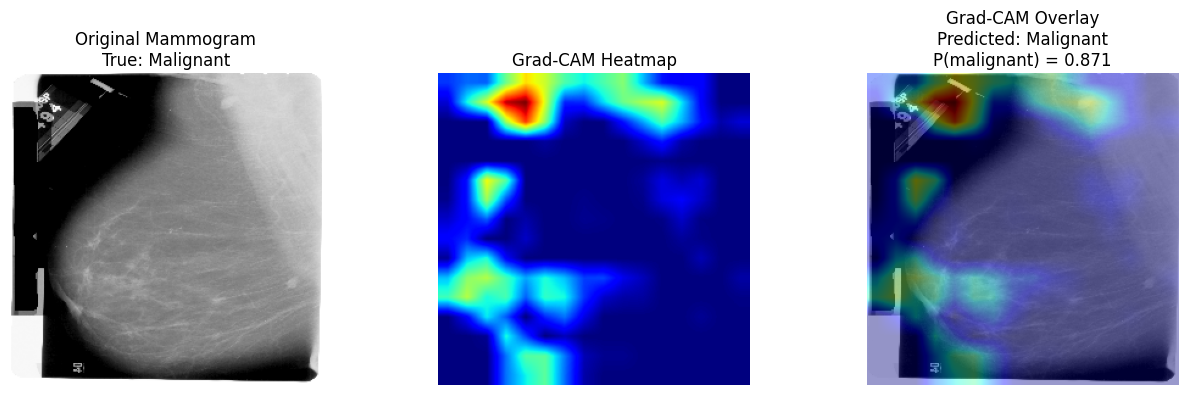


True Negative


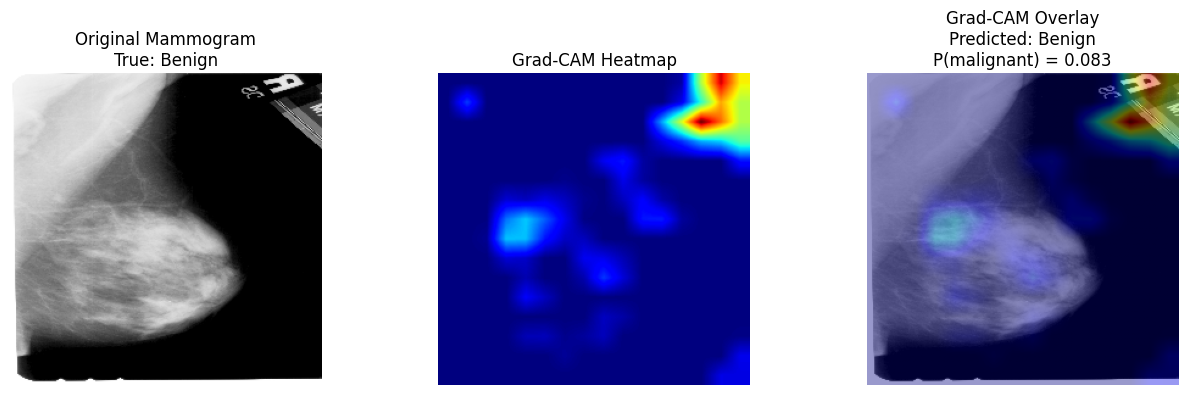


False Positive


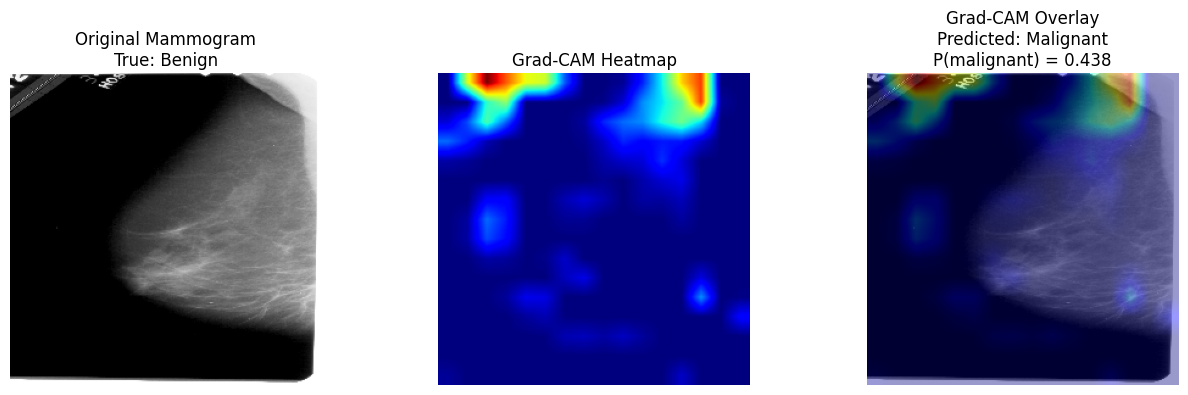


False Negative


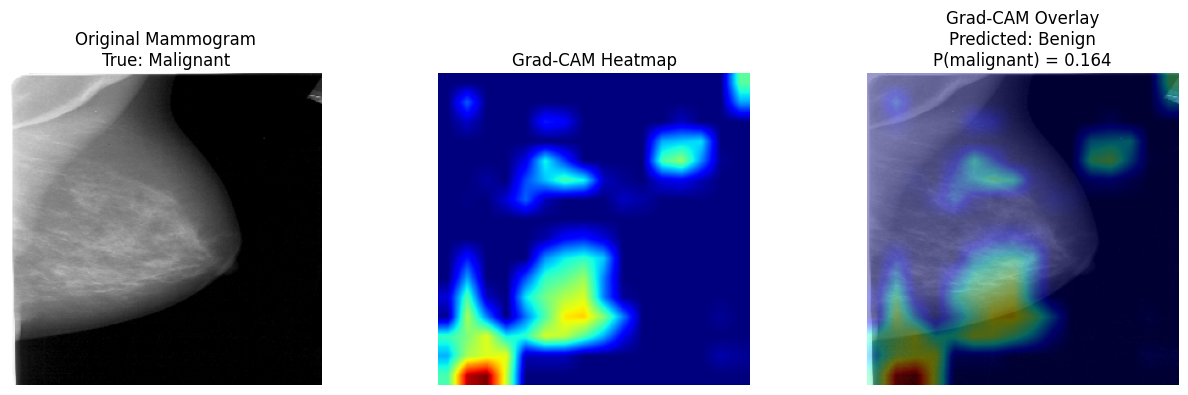

In [58]:
# Representative Grad-CAM Examples
gradcam_examples = {
    "True Positive": true_positive_idx[0],
    "True Negative": true_negative_idx[0],
    "False Positive": false_positive_idx[0],
    "False Negative": false_negative_idx[0]
}

for case_name, idx in gradcam_examples.items():

    print(
        "\n" + "=" * 60
    )

    print(
        case_name
    )

    print(
        "=" * 60
    )

    show_gradcam_example(
        idx
    )

### Grad-CAM Interpretation

The Grad-CAM examples show that model attention is not consistently restricted to suspicious breast regions. Some activation occurs near image boundaries or acquisition-related markings, including in correctly classified cases. The heatmaps are therefore interpreted as qualitative evidence of model behaviour rather than validated lesion localisation.

## 10.7 Grad-CAM Prediction Consistency Check

The probability produced through the Grad-CAM forward path is compared with the standard VGG16 prediction to confirm that explanation generation does not alter the classifier output.

In [59]:
# Verify that Grad-CAM and standard inference produce the same probability
idx = true_positive_idx[0]

img_path = test_df['real_path'].iloc[idx]

_, img_batch = prepare_gradcam_image(img_path)

# Normal model prediction
normal_prob = float(
    vgg_model.predict(img_batch, verbose=0)[0][0]
)

# Probability obtained inside Grad-CAM function
_, gradcam_prob = make_gradcam_heatmap(
    img_batch,
    vgg_model
)

print(f"Normal VGG prediction:   {normal_prob:.6f}")
print(f"Grad-CAM prediction:     {gradcam_prob:.6f}")
print(f"Difference:              {abs(normal_prob-gradcam_prob):.8f}")

Normal VGG prediction:   0.870924
Grad-CAM prediction:     0.870924
Difference:              0.00000012


# 11. Interactive Research Prototype

## 11.1 Export Final Model

The locked fine-tuned VGG16 model is saved as a standalone Keras model so that inference can be performed without rerunning the training pipeline.

In [60]:
# Export the final model for standalone deployment (Gradio app)
vgg_model.save('/content/drive/MyDrive/archive/final_vgg16_model.keras')
print("Saved final model for deployment")

Saved final model for deployment


## 11.2 Standalone Gradio Application

The saved final model is loaded into a Gradio interface that accepts a mammogram image and returns the predicted class, malignant-class probability, validation-selected threshold and corresponding Grad-CAM overlay. The interface is intended only as a research demonstration and not as a clinical diagnostic tool.

In [1]:
# Gradio Research Prototype
# Final model: fine-tuned VGG16

# Install Gradio in the current Colab runtime
!pip install -q gradio

# Imports
import numpy as np
import tensorflow as tf
import gradio as gr
import matplotlib.pyplot as plt

from google.colab import drive
from tensorflow.keras.applications.vgg16 import (
    preprocess_input as vgg_preprocess
)

# Mount Google Drive
drive.mount("/content/drive")

MODEL_PATH = (
    "/content/drive/MyDrive/archive/"
    "final_vgg16_model.keras"
)

IMG_SIZE = 256

# Locked validation-selected Youden's J threshold
SELECTED_THRESHOLD = 0.27

GRADCAM_LAYER = "block5_conv3"

vgg_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Final VGG16 model loaded successfully.")
print(f"Decision threshold: {SELECTED_THRESHOLD}")

# Image preprocessing
def prepare_image(pil_img):
    """
    Convert an uploaded PIL image to the same input format
    used by the fine-tuned VGG16 classifier.
    """
    img = np.array(
        pil_img.convert("L")
    )

    # Add channel dimension and resize
    img = tf.image.resize(
        img[..., np.newaxis],
        [IMG_SIZE, IMG_SIZE]
    )

    # Preserve grayscale image for display
    display_img = tf.squeeze(
        img
    ).numpy()

    # VGG16 requires 3 channels
    img_rgb = tf.image.grayscale_to_rgb(
        img
    )

    img_preprocessed = vgg_preprocess(
        img_rgb
    )

    img_batch = tf.expand_dims(
        img_preprocessed,
        axis=0
    )

    return display_img, img_batch

# Grad-CAM
def make_gradcam_heatmap(
    img_batch,
    model,
    conv_layer_name=GRADCAM_LAYER
):
    """
    Generate Grad-CAM for the malignant-class probability.
    """

    base_model = model.layers[0]

    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(
                conv_layer_name
            ).output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, features = feature_model(
            img_batch,
            training=False
        )

        x = features

        # Pass VGG16 features through the trained classification head
        for layer in model.layers[1:]:
            x = layer(
                x,
                training=False
            )

        malignant_score = x[:, 0]

    grads = tape.gradient(
        malignant_score,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return (
        heatmap.numpy(),
        float(malignant_score.numpy()[0])
    )

# Prediction + explanation
def predict_and_explain(
    pil_img,
    alpha=0.40
):

    if pil_img is None:
        return (
            None,
            "Upload a mammogram image first."
        )

    display_img, img_batch = prepare_image(
        pil_img
    )

    heatmap, probability = make_gradcam_heatmap(
        img_batch,
        vgg_model
    )

    # Resize Grad-CAM to model input size
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        [IMG_SIZE, IMG_SIZE]
    ).numpy().squeeze()

    # Normalise mammogram for visualisation
    original = display_img.astype(
        np.float32
    )

    original = (
        original - original.min()
    ) / (
        original.max()
        - original.min()
        + 1e-8
    )

    original_rgb = np.stack(
        [original] * 3,
        axis=-1
    )

    # Colour Grad-CAM heatmap
    coloured_heatmap = plt.get_cmap(
        "jet"
    )(
        heatmap_resized
    )[:, :, :3]

    # Overlay Grad-CAM on mammogram
    overlay = np.clip(
        (1 - alpha) * original_rgb
        + alpha * coloured_heatmap,
        0,
        1
    )

    overlay_uint8 = (
        overlay * 255
    ).astype(np.uint8)

    # Locked classification rule
    predicted_label = (
        "Malignant"
        if probability >= SELECTED_THRESHOLD
        else "Benign"
    )

    result_text = (
        f"**Prediction: {predicted_label}**\n\n"
        f"P(malignant) = {probability:.3f}\n\n"
        f"Decision threshold = "
        f"{SELECTED_THRESHOLD:.2f} "
        f"(validation-selected using Youden's J)\n\n"
        f"_Research prototype only — "
        f"not a validated diagnostic tool._"
    )

    return overlay_uint8, result_text

# Gradio interface
demo = gr.Interface(
    fn=predict_and_explain,

    inputs=[
        gr.Image(
            type="pil",
            label="Upload a mammogram (JPEG/PNG)"
        ),

        gr.Slider(
            minimum=0.1,
            maximum=0.8,
            value=0.40,
            step=0.05,
            label="Grad-CAM overlay strength"
        ),
    ],

    outputs=[
        gr.Image(
            label="Grad-CAM Overlay"
        ),

        gr.Markdown()
    ],

    title=(
        "Mammogram Benign/Malignant Classifier "
        "— Fine-Tuned VGG16"
    ),

    description=(
        "CM3070 Final Year Project research prototype. "
        "Upload a full mammogram to obtain the locked "
        "VGG16 classification and a Grad-CAM visualisation "
        "of regions influencing the prediction. "
        "Not for clinical use."
    )
)

# Launch application
demo.launch(
    share=True
)

Mounted at /content/drive
Final VGG16 model loaded successfully.
Decision threshold: 0.27
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfbb052d019fe4da18.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
